In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


<div style="text-align: left; background-color:#4e4e4e; font-family: Trebuchet MS; color:white; padding: 12px; line-height:1.25;border-radius:1px; margin-bottom: 0em; text-align: center; font-size: 38px;border-style: solid;border-color: dark green;">Heart Diseases: What are the indicators?</div>

<br> </br>
<div>    

<img src="https://images2.minutemediacdn.com/image/upload/c_fill,w_1080,ar_16:9,f_auto,q_auto,g_auto/shape%2Fcover%2Fsport%2F535618-istock-819924240-2470f65174198a2b48b33619995f99ad.jpg" width="550/">    
</div>

<div style="text-align: left; background-color:#4e4e4e; font-family: Trebuchet MS; color:white; padding: 12px; line-height:1.25;border-radius:1px; margin-bottom: 0em; text-align: center; font-size: 12px;border-style: solid;border-color: dark green;"><p><b><a href="https://www.mentalfloss.com/article/535618/super-ekg-could-diagnose-heart-disease-90-seconds" target="">Image source</a></b></p></div>


# 0. **Introduction** <a class="anchor" id="0"></a>
"Heart disease, also referred as cardiovascular diseases, is broad term used for diseases and conditions affecting the heart and circulatory system. It is a major cause of disability all around the world. Since heart is amongst the most vital organs of the body, its diseases affect other organs and part of the body as well. There are several different types and forms of heart diseases. The most common ones cause narrowing or blockage of the coronary arteries, malfunctioning in the valves of the heart, enlargement in the size of heart and several others leading to **heart failure** and **heart attack**." [[Source](https://www.indushealthplus.com/heart-diseases.html)]

<blockquote style="margin-right:auto; margin-left:auto; color:white; background-color:#4e4e4e; padding: 1em; margin:24px;">

<font color="white" size=+1.0><b>Key facts according to WHO (World Health Organaizations)</b></font>  
        
<ul>
<li> Cardiovascular diseases (CVDs) are the leading cause of death globally.
<li> An estimated 17.9 million people died from CVDs in 2019, representing 32% of all global deaths. Of these deaths, 85% were due to heart attack and stroke.
<li> Over three quarters of CVD deaths take place in low- and middle-income countries.
<li> Out of the 17 million premature deaths (under the age of 70) due to noncommunicable diseases in 2019, 38% were caused by CVDs.
<li> Most cardiovascular diseases can be prevented by addressing behavioural risk factors such as tobacco use, unhealthy diet and obesity, physical inactivity and harmful use of alcohol.
<li> It is important to detect cardiovascular disease as early as possible so that management with counselling and medicines can begin.                                                                                                                                 
    
</ul>        
</blockquote>

#### **Objectives**
This notebook has two main objectives:
* Explore the heart disease dataset using exploratory data analysis (EDA)
* Exercise with classification algorithms for prediction (modelling)
---

<a id="top"></a>

## **Table of Contents**

* [0. Introduction](#0)
* [1. Exploratory Data Analysis](#1)
    * [1.1 Data Dictionary](#1.1)
    * [1.2 Data Pre-processing](#1.2)
    * [1.3 Exploring Features](#1.3)
    * [1.4 Correlations Heatmap](#1.4)
    * [1.5 EDA Summary](#1.5)
* [2. Predictions](#2)
    * [2.1 Scikit Learn Classifiers](#2.1)
    * [2.2 Catboost, Lgbm and Xgboost](#2.2)
    * [2.3 Model Explainability](#2.3)
* [3. Concluding Remarks](#3)
* [4. Reference](#4)


---
# 1. **Exploratory Data Analysis** <a class="anchor" id="1"></a>
---

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import seaborn as sns
from IPython.core.display import HTML
import matplotlib.pyplot as plt
from scipy.stats import uniform



# import warnings
# warnings.filterwarnings('ignore')

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

In [2]:
dir(pd)

['ArrowDtype',
 'BooleanDtype',
 'Categorical',
 'CategoricalDtype',
 'CategoricalIndex',
 'DataFrame',
 'DateOffset',
 'DatetimeIndex',
 'DatetimeTZDtype',
 'ExcelFile',
 'ExcelWriter',
 'Flags',
 'Float32Dtype',
 'Float64Dtype',
 'Grouper',
 'HDFStore',
 'Index',
 'IndexSlice',
 'Int16Dtype',
 'Int32Dtype',
 'Int64Dtype',
 'Int8Dtype',
 'Interval',
 'IntervalDtype',
 'IntervalIndex',
 'MultiIndex',
 'NA',
 'NaT',
 'NamedAgg',
 'Period',
 'PeriodDtype',
 'PeriodIndex',
 'RangeIndex',
 'Series',
 'SparseDtype',
 'StringDtype',
 'Timedelta',
 'TimedeltaIndex',
 'Timestamp',
 'UInt16Dtype',
 'UInt32Dtype',
 'UInt64Dtype',
 'UInt8Dtype',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__docformat__',
 '__file__',
 '__git_version__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '__version__',
 '_built_with_meson',
 '_config',
 '_is_numpy_dev',
 '_libs',
 '_pandas_datetime_CAPI',
 '_pandas_parser_CAPI',
 '_testing',
 '_typing',
 '_version_meson',
 'annota

In [5]:
data = pd.read_csv("heart.csv")

In [6]:

print('Shape of the data is ', data.shape)

Shape of the data is  (303, 14)


In [7]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [8]:
data.shape

(303, 14)

In [9]:
data.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [10]:
data.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


---
## 1.1 **Data Dictionary** <a class="anchor" id="1.1"></a>

1. age: age in years
2. sex: sex
    * 1 = male
    * 0 = female
3. cp: chest pain type
    * Value 0: typical angina
    * Value 1: atypical angina
    * Value 2: non-anginal pain
    * Value 3: asymptomatic


Chest pain from angina happens when your heart muscle doesn’t get enough oxygen-rich blood. It’s not a disease by itself but a symptom of an underlying heart problem, usually coronary artery disease (narrowing or blockage of the arteries that supply the heart).

What it feels like

People often describe angina as a tightness, heaviness, squeezing, or pressure in the chest.

It can spread to the arms, neck, jaw, shoulder, or back.

Some feel it more as shortness of breath, fatigue, or indigestion-like discomfort instead of sharp pain.

Why it happens

The heart needs more oxygen during activities like walking uphill, exercising, or when stressed.

If the arteries are narrowed by fatty deposits (plaque), the blood flow can’t increase enough to meet that demand.

This mismatch between demand and supply causes the pain or pressure.

Types of angina

Stable angina

Predictable. Comes with exertion or stress, goes away with rest or medication (like nitroglycerin).

Unstable angina

Unpredictable. Can occur even at rest, lasts longer, and may signal a heart attack is coming. This is a medical emergency.

Variant (Prinzmetal’s) angina

Caused by a sudden spasm of the coronary artery. Less common.


4. trestbps: resting blood pressure (in mm Hg on admission to the hospital)
5. chol: serum cholesterol in mg/dl
6. fbs: (fasting blood sugar > 120 mg/dl)
    * 1 = true;
    * 0 = false
7. restecg: resting electrocardiographic results
    * Value 0: normal
    * Value 1: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)
    * Value 2: showing probable or definite left ventricular hypertrophy by Estes' criteria
8. thalach: maximum heart rate achieved
9. exang: exercise induced angina
    * 1 = yes
    * 0 = no
10. oldpeak = ST depression induced by exercise relative to rest
11. slope: the slope of the peak exercise ST segment
    * Value 0: upsloping
    * Value 1: flat
    * Value 2: downsloping
12. ca: number of major vessels (0-3) colored by flourosopy
13. thal:
    * 0 = `error (in the original dataset 0 maps to NaN's)`
    * 1 = fixed defect
    * 2 = normal
    * 3 = reversable defect
14. target (the label):
    * 0 = no disease,
    * 1 = disease
---    
**Note on the target label**:

`Diagnosis of heart disease (angiographic disease status)
Value 0: < 50% diameter narrowing
Value 1: > 50% diameter narrowing`
    


---

<a href="#top">☝️ Back to top</a>

## 1.2 **Data pre-processing** <a class="anchor" id="1.2"></a>
### 1.2.1 Drop faulty data
We will drop 7 rows that are not good data.

In [12]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [13]:
# This line filters the dataset called "data" and keeps only the rows
# where the value in the column named 'ca' is less than 4.
#
# Here's what happens step-by-step:
# 1. data['ca']   → selects the column 'ca' from the DataFrame (like one column in Excel).
# 2. data['ca'] < 4 → compares each value in that column to 4, giving True or False for every row.
#                     Example: [0, 2, 4, 3] becomes [True, True, False, True].
# 3. data[data['ca'] < 4] → uses those True/False results to keep only the rows marked True.
#                           So rows where 'ca' >= 4 are removed.
# 4. The "=" sign assigns this new filtered DataFrame back to the same variable name "data",
#    replacing the old one with the cleaned version.
#
# In short: this line removes rows where 'ca' has an invalid or impossible value (4 or more).
data = data[data['ca'] < 4]  # drop rows with invalid 'ca' values


# This line works the same way as the one above, but for the column 'thal'.
#
# Step-by-step:
# 1. data['thal'] → selects the column named 'thal' from the dataset.
# 2. data['thal'] > 0 → checks each value to see if it’s greater than zero,
#                       producing a list of True/False values for every row.
# 3. data[data['thal'] > 0] → keeps only the rows where that condition is True.
#                             Any row with 'thal' <= 0 is dropped.
# 4. Again, the "=" sign replaces the old dataset with the new filtered one.
#
# In short: this removes rows with missing or invalid 'thal' values (0 or negative).
data = data[data['thal'] > 0]  # drop rows with invalid 'thal' values


# This line prints out how many rows (entries) remain in the dataset after cleaning.
#
# Step-by-step:
# 1. len(data) → counts the number of rows currently in the DataFrame.
# 2. The 'f' before the string means "formatted string" (f-string). It lets you insert
#    variables directly into text using curly braces {}.
# 3. {len(data)} is replaced by the actual number of rows when printed.
# 4. The text inside print() is then shown in the output window or console.
#
# Example output: "The length of the data now is 299 instead of 303!"
print(f'The length of the data now is {len(data)} instead of 303!')

The length of the data now is 296 instead of 303!


### 1.2.2 Rename columns for the sake of clarity
* The feature names in the dataset are abbreviated and hard to understand their meaning. A full medical/technical name is hard enough to understand for most of us let alone their short form. So to make them a little bit easier to read we will, here under, change the column names of the data frame using information from the UCL data repository.
* We'll also replace the coded categories (0, 1, 2,..) to their medical meaning ('atypical angina', 'typical angina', etc. for example)
* **Note**: I borrowed [Rob Harrand's](https://www.kaggle.com/tentotheminus9/what-causes-heart-disease-explaining-the-model) idea of re-naming the columns.

In [14]:
# This line renames several column names in the DataFrame called "data"
# to make them more descriptive and easier to understand.
#
# In pandas, a DataFrame is like a spreadsheet with rows and columns.
# The method `.rename()` is used to change the names of one or more columns or rows.
#
# Syntax breakdown:
# data.rename(columns = {...}, errors = "raise")
# └── 'columns' tells pandas which columns to rename and what their new names should be.
#     You provide these as a dictionary: {'old_name': 'new_name', 'old_name2': 'new_name2', ...}
# └── 'errors' controls what happens if you try to rename a column that doesn’t exist.
#     - "raise" means: if any of the old column names are missing, stop the code and show an error.
#     - "ignore" would mean: skip missing ones and rename only those that exist.
#
# Let’s go through what’s inside the dictionary step by step:
# Each item inside { } has a key (before the :) and a value (after the :).
# The key is the *old column name*, and the value is the *new column name*.
#
# For example:
#   'cp': 'chest_pain_type'      → Rename the column 'cp' to 'chest_pain_type'
#   'trestbps': 'resting_blood_pressure' → Rename 'trestbps' to 'resting_blood_pressure'
#   'chol': 'cholesterol'        → Rename 'chol' to 'cholesterol'
#   'fbs': 'fasting_blood_sugar' → Rename 'fbs' to 'fasting_blood_sugar'
#   'restecg': 'resting_electrocardiogram' → Rename 'restecg' to 'resting_electrocardiogram'
#   'thalach': 'max_heart_rate_achieved'  → Rename 'thalach' to 'max_heart_rate_achieved'
#   'exang': 'exercise_induced_angina'    → Rename 'exang' to 'exercise_induced_angina'
#   'oldpeak': 'st_depression'   → Rename 'oldpeak' to 'st_depression'
#   'slope': 'st_slope'          → Rename 'slope' to 'st_slope'
#   'ca': 'num_major_vessels'    → Rename 'ca' to 'num_major_vessels'
#   'thal': 'thalassemia'        → Rename 'thal' to 'thalassemia'
#
# The outer parentheses are used to make the code block visually clearer and prevent errors
# when the dictionary spans multiple lines.
#
# Finally, the entire operation assigns the result back to 'data'.
# That means the DataFrame "data" is updated with these new column names.
data = data.rename(
    columns = {
        'cp': 'chest_pain_type',
        'trestbps': 'resting_blood_pressure',
        'chol': 'cholesterol',
        'fbs': 'fasting_blood_sugar',
        'restecg': 'resting_electrocardiogram',
        'thalach': 'max_heart_rate_achieved',
        'exang': 'exercise_induced_angina',
        'oldpeak': 'st_depression',
        'slope': 'st_slope',
        'ca': 'num_major_vessels',
        'thal': 'thalassemia'
    },
    errors = "raise"  # If any old column name doesn’t exist, show an error instead of ignoring it
)

In [ ]:
data.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,resting_electrocardiogram,max_heart_rate_achieved,exercise_induced_angina,st_depression,st_slope,num_major_vessels,thalassemia,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
data.tail()

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,resting_electrocardiogram,max_heart_rate_achieved,exercise_induced_angina,st_depression,st_slope,num_major_vessels,thalassemia,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [ ]:
# The following lines safely replace numeric category codes in the dataset
# with meaningful text labels using .loc[] — a pandas method that allows you
# to select specific rows and columns at the same time, without warnings or ambiguity.
#
# This process is called *data labeling* or *value mapping*.
# It helps make your dataset easier to read, understand, and interpret for humans.

# --------------------------------------------------------------------
# SYNTAX REMINDER
# --------------------------------------------------------------------
# The general structure of each line looks like this:
#
#   data.loc[row_condition, 'column_name'] = new_value
#
# Let’s break it down clearly:
# 1. data → your dataset, stored as a "DataFrame" (like an Excel table with rows and columns).
# 2. .loc[] → means "locate". It’s a pandas function used to find and modify specific rows
#    and columns that meet certain conditions.
# 3. Inside the square brackets [ ], there are two parts separated by a comma:
#       - The first part (before the comma) specifies *which rows* to target.
#         Example: data['sex'] == 0 → find rows where the value in the 'sex' column equals 0.
#       - The second part (after the comma) specifies *which column* to modify.
#         Example: 'sex' → modify the column named 'sex'.
# 4. == → means "is equal to". It checks whether each value matches the number you specify.
#    Example: [1, 0, 1] == 0 → [False, True, False]
# 5. = (a single equal sign) → means "assign" or "replace". It changes the old value
#    with a new one in the selected cells.
# 6. The text in quotes (like 'female') → is a string, meaning plain text.
#    Strings are used to store words or labels, not numbers.

# --------------------------------------------------------------------
# SEX COLUMN
# --------------------------------------------------------------------
# The 'sex' column uses numbers to represent gender:
# 0 = female, 1 = male.
# These lines replace those numbers with the actual text labels.

# If the value is 0, replace it with 'female'
data.loc[data['sex'] == 0, 'sex'] = 'female'

# If the value is 1, replace it with 'male'
data.loc[data['sex'] == 1, 'sex'] = 'male'


# --------------------------------------------------------------------
# CHEST PAIN TYPE COLUMN
# --------------------------------------------------------------------
# The 'chest_pain_type' column contains four numeric categories representing
# different types of chest pain. These are replaced with descriptive text.

# 0 = typical angina (chest pain caused by reduced blood flow)
data.loc[data['chest_pain_type'] == 0, 'chest_pain_type'] = 'typical angina'

# 1 = atypical angina (chest pain not related to physical exertion)
data.loc[data['chest_pain_type'] == 1, 'chest_pain_type'] = 'atypical angina'

# 2 = non-anginal pain (chest pain unrelated to heart problems)
data.loc[data['chest_pain_type'] == 2, 'chest_pain_type'] = 'non-anginal pain'

# 3 = asymptomatic (no chest pain or visible symptoms)
data.loc[data['chest_pain_type'] == 3, 'chest_pain_type'] = 'asymptomatic'


# --------------------------------------------------------------------
# FASTING BLOOD SUGAR COLUMN
# --------------------------------------------------------------------
# This column shows whether a person's fasting blood sugar is above or below 120 mg/dL.
# (Note: the correct unit is mg/dL, not mg/ml.)

# 0 = blood sugar ≤ 120 mg/dL
data.loc[data['fasting_blood_sugar'] == 0, 'fasting_blood_sugar'] = '≤ 120 mg/dL'

# 1 = blood sugar > 120 mg/dL
data.loc[data['fasting_blood_sugar'] == 1, 'fasting_blood_sugar'] = '> 120 mg/dL'


# --------------------------------------------------------------------
# RESTING ELECTROCARDIOGRAM COLUMN
# --------------------------------------------------------------------
# This column records the results of an ECG (electrocardiogram) test.

# 0 = normal
data.loc[data['resting_electrocardiogram'] == 0, 'resting_electrocardiogram'] = 'normal'

# 1 = ST-T wave abnormality (abnormal heart electrical pattern)
data.loc[data['resting_electrocardiogram'] == 1, 'resting_electrocardiogram'] = 'ST-T wave abnormality'

# 2 = left ventricular hypertrophy (thickening of the left heart chamber)
data.loc[data['resting_electrocardiogram'] == 2, 'resting_electrocardiogram'] = 'left ventricular hypertrophy'


# --------------------------------------------------------------------
# EXERCISE-INDUCED ANGINA COLUMN
# --------------------------------------------------------------------
# This column shows whether the patient experienced angina (chest pain)
# during physical exercise.

# 0 = no angina during exercise
data.loc[data['exercise_induced_angina'] == 0, 'exercise_induced_angina'] = 'no'

# 1 = angina occurred during exercise
data.loc[data['exercise_induced_angina'] == 1, 'exercise_induced_angina'] = 'yes'


# --------------------------------------------------------------------
# ST SLOPE COLUMN
# --------------------------------------------------------------------
# The 'st_slope' column describes the slope of the ST segment in an ECG graph.
# This can indicate different heart conditions.

# 0 = upsloping (ST segment rises)
data.loc[data['st_slope'] == 0, 'st_slope'] = 'upsloping'

# 1 = flat (ST segment stays level)
data.loc[data['st_slope'] == 1, 'st_slope'] = 'flat'

# 2 = downsloping (ST segment falls)
data.loc[data['st_slope'] == 2, 'st_slope'] = 'downsloping'


# --------------------------------------------------------------------
# THALASSEMIA COLUMN
# --------------------------------------------------------------------
# Thalassemia is a blood disorder measured here as heart-related defects
# detected through imaging tests.
# Note: In some datasets, these codes might differ, so always check your unique values first.

# 1 = fixed defect (heart issue that does not change with exercise)
data.loc[data['thalassemia'] == 1, 'thalassemia'] = 'fixed defect'

# 2 = normal (no detected abnormality)
data.loc[data['thalassemia'] == 2, 'thalassemia'] = 'normal'

# 3 = reversible defect (heart issue that improves or disappears during exercise)
data.loc[data['thalassemia'] == 3, 'thalassemia'] = 'reversible defect'


# --------------------------------------------------------------------
# SUMMARY
# --------------------------------------------------------------------
# - .loc[] safely finds and edits rows in a DataFrame without warnings.
# - Each line searches for a numeric code in one column and replaces it with clear text.
# - This process improves readability and prepares the data for visualization or analysis.

/tmp/ipython-input-2810910467.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'female' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[data['sex'] == 0, 'sex'] = 'female'
/tmp/ipython-input-2810910467.py:52: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'typical angina' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[data['chest_pain_type'] == 0, 'chest_pain_type'] = 'typical angina'
/tmp/ipython-input-2810910467.py:71: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '≤ 120 mg/dL' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[data['fasting_blood_sugar'] == 0, 'fasting_blood_sugar'] = '≤ 120 m

In [ ]:
data.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,resting_electrocardiogram,max_heart_rate_achieved,exercise_induced_angina,st_depression,st_slope,num_major_vessels,thalassemia,target
0,63,male,asymptomatic,145,233,> 120 mg/dL,normal,150,no,2.3,upsloping,0,fixed defect,1
1,37,male,non-anginal pain,130,250,≤ 120 mg/dL,ST-T wave abnormality,187,no,3.5,upsloping,0,normal,1
2,41,female,atypical angina,130,204,≤ 120 mg/dL,normal,172,no,1.4,downsloping,0,normal,1
3,56,male,atypical angina,120,236,≤ 120 mg/dL,ST-T wave abnormality,178,no,0.8,downsloping,0,normal,1
4,57,female,typical angina,120,354,≤ 120 mg/dL,ST-T wave abnormality,163,yes,0.6,downsloping,0,normal,1


In [ ]:
data.tail()

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,resting_electrocardiogram,max_heart_rate_achieved,exercise_induced_angina,st_depression,st_slope,num_major_vessels,thalassemia,target
298,57,female,typical angina,140,241,≤ 120 mg/dL,ST-T wave abnormality,123,yes,0.2,flat,0,reversible defect,0
299,45,male,asymptomatic,110,264,≤ 120 mg/dL,ST-T wave abnormality,132,no,1.2,flat,0,reversible defect,0
300,68,male,typical angina,144,193,> 120 mg/dL,ST-T wave abnormality,141,no,3.4,flat,2,reversible defect,0
301,57,male,typical angina,130,131,≤ 120 mg/dL,ST-T wave abnormality,115,yes,1.2,flat,1,reversible defect,0
302,57,female,atypical angina,130,236,≤ 120 mg/dL,normal,174,no,0.0,flat,1,normal,0


In [ ]:
data.dtypes

,0
age,int64
sex,object
chest_pain_type,object
resting_blood_pressure,int64
cholesterol,int64
fasting_blood_sugar,object
resting_electrocardiogram,object
max_heart_rate_achieved,int64
exercise_induced_angina,object
st_depression,float64


In [ ]:
data.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,resting_electrocardiogram,max_heart_rate_achieved,exercise_induced_angina,st_depression,st_slope,num_major_vessels,thalassemia,target
0,63,male,asymptomatic,145,233,> 120 mg/dL,normal,150,no,2.3,upsloping,0,fixed defect,1
1,37,male,non-anginal pain,130,250,≤ 120 mg/dL,ST-T wave abnormality,187,no,3.5,upsloping,0,normal,1
2,41,female,atypical angina,130,204,≤ 120 mg/dL,normal,172,no,1.4,downsloping,0,normal,1
3,56,male,atypical angina,120,236,≤ 120 mg/dL,ST-T wave abnormality,178,no,0.8,downsloping,0,normal,1
4,57,female,typical angina,120,354,≤ 120 mg/dL,ST-T wave abnormality,163,yes,0.6,downsloping,0,normal,1


### 1.2.3 Grouping Features (by data type)
* As we have seen above there are three datatypes i.e **object**, **int** and **floats**. Let's group them according to type.


In [25]:
# FEATURE GROUPING (what each variable list is for)
# --------------------------------------------------------------------
# We are organizing column names into groups based on the type of data they hold.
# This helps later when we apply the right preprocessing to each group.
# Grouping columns by "type" helps us choose the right preprocessing later.
#
# There are two big families:
#   1) NUMERICAL features  → numbers you can do math on (add, average, scale).
#   2) CATEGORICAL features → labels/text that describe a category (not numbers to calculate with).
#
# Within CATEGORICAL features, there are common subtypes:
#   A) BINARY (two categories)      → e.g., 'yes'/'no', 'male'/'female'
#   B) NOMINAL (3+ categories, no order) → e.g., 'red','blue','green' (no natural ranking)
#   C) ORDINAL (3+ categories, WITH order) → e.g., 'low','medium','high' (there IS a ranking)
#
# Why this matters:
# - NUMERICAL features are fed directly into models (often after scaling).
# - BINARY/NOMINAL features need to be turned into numbers first (e.g., one-hot encoding).
# - ORDINAL features can be mapped to ordered numbers (e.g., low=1, medium=2, high=3).
#
# In THIS dataset, we have numerical, binary, and nominal features.
# (We don’t have a clear ordinal feature here.)

# --------------------------------------------------------------------
# 1) NUMERICAL FEATURES
# --------------------------------------------------------------------
# These are measured quantities or counts. You can compute things like mean,
# standard deviation, and apply scaling (StandardScaler/MinMax).
num_feats = [
    'age',                      # age in years (numeric)
    'cholesterol',              # serum cholesterol in mg/dL (numeric)
    'resting_blood_pressure',   # systolic blood pressure in mm Hg (numeric)
    'max_heart_rate_achieved',  # beats per minute (numeric)
    'st_depression',            # ST depression relative to rest (numeric, can be decimals)
    'num_major_vessels'         # count of major vessels colored by fluoroscopy: 0..3 (numeric count)
]

# --------------------------------------------------------------------
# 2) CATEGORICAL (BINARY) FEATURES
# --------------------------------------------------------------------
# These have exactly TWO possible values (two labels). They answer yes/no type questions.
# You typically convert them to numbers like 0/1 or use one-hot encoding (creates two columns).
# Examples outside medicine: 'owns_car' → 'yes'/'no'
bin_feats = [
    'sex',                      # 'female' or 'male'
    'fasting_blood_sugar',      # '≤ 120 mg/dL' or '> 120 mg/dL'
    'exercise_induced_angina',  # 'no' or 'yes'
    'target'                    # usually 0 (no disease) or 1 (disease). Keep as numeric for modeling,
                                # but we list it here to remember it’s a binary class label.
]

# --------------------------------------------------------------------
# 3) CATEGORICAL (NOMINAL, MULTI-CLASS) FEATURES
# --------------------------------------------------------------------
# These have THREE OR MORE categories with NO natural order.
# 'A' is not greater/less than 'B' — they’re just different groups.
# Models can’t read text directly, so we turn each category into indicator columns
# (one-hot encoding): e.g., 'red','blue','green' → three 0/1 columns.
nom_feats = [
    'chest_pain_type',            # 'typical angina', 'atypical angina', 'non-anginal pain', 'asymptomatic'
    'resting_electrocardiogram',  # 'normal', 'ST-T wave abnormality', 'left ventricular hypertrophy'
    'st_slope',                   # 'upsloping', 'flat', 'downsloping'
    'thalassemia'                 # 'normal', 'fixed defect', 'reversible defect' (encoding can vary by source)
]

# (For completeness: ORDINAL features would be something like 'risk_level' = 'low','medium','high'.
# Those HAVE order, so you can map them to numbers like 1,2,3 in that order. Not used here.)

# --------------------------------------------------------------------
# 4) ALL CATEGORICAL FEATURES TOGETHER
# --------------------------------------------------------------------
# We often keep a single list of all categorical columns for convenience
# when applying encoders (e.g., OneHotEncoder on nominals, binary mapping on binaries).
cat_feats = nom_feats + bin_feats

In [26]:
data.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,resting_electrocardiogram,max_heart_rate_achieved,exercise_induced_angina,st_depression,st_slope,num_major_vessels,thalassemia,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## 1.3 **Exploring Features/Target** <a class="anchor" id="1.3"></a>

In this section we'll investigate all the features (including the target) in detail. We will look at the statistical summary when possible and the distributions of some of them as well, starting from the target.

### 1.3.1 Target distribution

We observe that the target is fairly balanced with ~46% with no heart disease and ~54% with heart disease. So no need to worry about target imbalance.


In [27]:
# Use list comprehension to generate an HTML string where each color is represented by a colored rectangle
# - For each color 'c' in the 'mypal' list:
#   * We create a <div> HTML element with inline CSS that:
#       - Sets display:inline-block so multiple boxes appear side by side
#       - Defines the width (100px) and height (50px) of the color box
#       - Uses the background-color property to fill the box with the hex color value
#       - Adds a small margin between boxes (3px)
#       - Displays the hex code text inside the box (the string '{c}' is replaced by the color code)
# - ''.join([...]) joins all the HTML div strings into one long HTML block
# - The HTML() function tells Jupyter to render this block as formatted HTML instead of plain text



from IPython.display import HTML

mypal = ['#FC05FB', '#FEAEFE', '#FCD2FC', '#F3FEFA', '#B4FFE4', '#3FFEBA', '#F6F5F4', 'pink']
HTML(''.join([f'<div style="display:inline-block; width:100px; height:50px; background-color:{c}; margin:3px;">{c}</div>' for c in mypal]))

C:\Users\Acity\AppData\Local\Temp\ipykernel_14776\396068909.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=data['target'], palette=mypal[1::4])


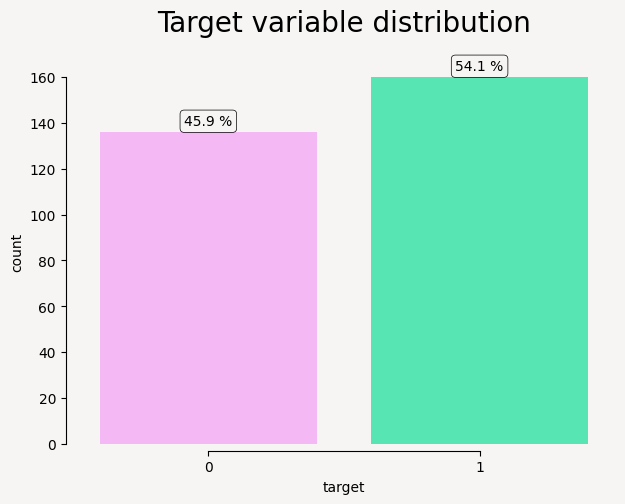

In [28]:


# Create a list of custom colors (hex color codes) to style the bars.
# Hex codes are 6-digit color values starting with "#", common in web and graphics design.
mypal = ['#FC05FB', '#FEAEFE', '#FCD2FC', '#F3FEFA', '#B4FFE4', '#3FFEBA']

# Create a blank "figure" — think of this as the drawing canvas where your chart will appear.
# figsize=(7, 5) means the width is 7 inches and the height is 5 inches.
# facecolor sets the background color of the whole figure (outside the plot area).
plt.figure(figsize=(7, 5), facecolor='#F6F5F4')

# Calculate the total number of rows (data points) in your dataset.
# len(data) gives how many entries are in 'data'.
# We convert it to a float number (decimal) to make later division produce decimal results.
total = float(len(data))

# Create a count plot (a type of bar chart) using Seaborn.
# sns.countplot() automatically counts how many times each unique value appears in the chosen column.
# x=data['target'] means: use the values from the 'target' column on the x-axis.
#
# Example: If 'target' has ['Yes', 'No', 'Yes'], the bars will show "Yes" = 2 and "No" = 1.
#
# palette=mypal[1::4] controls the bar colors.
# mypal[1::4] means: "start at index 1 (the second color in the list), and take every 4th color".
# So it might pick colors like mypal[1] and mypal[5].
ax = sns.countplot(x=data['target'], palette=mypal[1::4])

# Change the background color inside the plot area (where the bars are drawn).
ax.set_facecolor('#F6F5F4')

# Go through each "bar" in the chart one by one.
# In Matplotlib (which Seaborn uses internally), each bar is a "patch" object.
# ax.patches returns a list of all the bars drawn on the plot.
for p in ax.patches:

    # Get the height of the bar — this represents how tall it is (the count value).
    # Example: if a category appears 50 times, height = 50.
    height = p.get_height()

    # Now we’ll place text above each bar to show its percentage.
    # p.get_x() gives the x-coordinate of the left edge of the bar.
    # p.get_width() gives the width of the bar.
    # So (p.get_x() + p.get_width() / 2) finds the horizontal midpoint of the bar,
    # ensuring the text appears exactly in the center of it.
    #
    # height + 3 means we position the text slightly above the top of the bar,
    # adding 3 "units" of space so it doesn’t overlap with the bar itself.
    #
    # '{:1.1f} %'.format((height / total) * 100) converts the count to a percentage:
    #  (height / total) gives the proportion (e.g., 0.25),
    #  multiply by 100 to get percent (25.0),
    #  and {:1.1f} keeps one digit after the decimal point (25.0 %).
    #
    # ha="center" means the text will be horizontally centered.
    #
    # bbox creates a small border box around the text to make it readable.
    # - facecolor='none': transparent inside
    # - edgecolor='black': black border
    # - boxstyle='round': rounded corners
    # - linewidth=0.5: thin border line
    ax.text(
        p.get_x() + p.get_width() / 2.,       # center of the bar on the x-axis
        height + 3,                           # position slightly above the top of the bar
        '{:1.1f} %'.format((height / total) * 100),  # show the percentage value
        ha="center",                          # center align the text horizontally
        bbox=dict(
            facecolor='none',                 # transparent background
            edgecolor='black',                # black border
            boxstyle='round',                 # rounded edges
            linewidth=0.5                     # thin border line
        )
    )

# Set the chart title.
# fontsize controls the size of the title text.
# y=1.05 slightly lifts the title upward so it doesn’t sit directly on the chart.
ax.set_title('Target variable distribution', fontsize=20, y=1.05)

# sns.despine() removes border lines (spines) around the chart for a cleaner style.
# right=True removes the right-side border line.
sns.despine(right=True)

# The second call removes additional borders and trims extra white space around the chart.
# offset=5 adds a small gap (5 points) between the remaining spines and the data.
# trim=True shortens the spines to match the start and end of the data area.
sns.despine(offset=5, trim=True)


### 1.3.2 Numerical Features

#### Statistical summary

For the numerical features we can apply the handy pandas `data.describe()` method and get the global statistical summary. Key figures are highlighted below.

In [ ]:
data[num_feats].describe().T

# WHAT THIS LINE DOES (step by step)
# ---------------------------------------------------------------
# data[num_feats].describe().T
#
# 1) data
#    - Your entire table (a pandas DataFrame).
#    - Think of it like an Excel sheet with rows and columns.

# 2) data[num_feats]
#    - Selects ONLY the columns listed in the Python list named `num_feats`.
#    - `num_feats` should be a list of column names (strings), e.g.:
#        num_feats = ['age', 'cholesterol', 'resting_blood_pressure', ...]
#    - The result is a smaller DataFrame that contains just those numeric columns.

# 3) .describe()
#    - Asks pandas to compute summary statistics for each selected column.
#    - For numeric columns, it returns these rows (one row per statistic):
#        count : how many non-missing values there are (NaNs are excluded)
#        mean  : the average value
#        std   : standard deviation (how spread out the values are)
#        min   : the smallest value
#        25%   : the 25th percentile (lower quartile; 25% of values are <= this)
#        50%   : the 50th percentile (median; half the values are <= this)
#        75%   : the 75th percentile (upper quartile; 75% of values are <= this)
#        max   : the largest value
#    - The output at this point is a DataFrame where:
#        * Rows = statistics (count, mean, std, min, 25%, 50%, 75%, max)
#        * Columns = your feature names from `num_feats`

# 4) .T
#    - `.T` means "transpose" (swap rows and columns).
#    - After transposing:
#        * Rows   = your feature names (one row per column/feature)
#        * Columns= the statistics (count, mean, std, min, 25%, 50%, 75%, max)
#    - Why transpose? It can be easier to read when each feature is a ROW and
#      the statistics are the COLUMN headers.


,count,mean,std,min,25%,50%,75%,max
age,296.0,54.523649,9.059471,29.0,48.0,56.0,61.00,77.0
cholesterol,296.0,247.155405,51.977011,126.0,211.0,242.5,275.25,564.0
resting_blood_pressure,296.0,131.604730,17.726620,94.0,120.0,130.0,140.00,200.0
max_heart_rate_achieved,296.0,149.560811,22.970792,71.0,133.0,152.5,166.00,202.0
st_depression,296.0,1.059122,1.166474,0.0,0.0,0.8,1.65,6.2
num_major_vessels,296.0,0.679054,0.939726,0.0,0.0,0.0,1.00,3.0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 296 entries, 0 to 302
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        296 non-null    int64  
 1   sex                        296 non-null    object 
 2   chest_pain_type            296 non-null    object 
 3   resting_blood_pressure     296 non-null    int64  
 4   cholesterol                296 non-null    int64  
 5   fasting_blood_sugar        296 non-null    object 
 6   resting_electrocardiogram  296 non-null    object 
 7   max_heart_rate_achieved    296 non-null    int64  
 8   exercise_induced_angina    296 non-null    object 
 9   st_depression              296 non-null    float64
 10  st_slope                   296 non-null    object 
 11  num_major_vessels          296 non-null    int64  
 12  thalassemia                296 non-null    object 
 13  target                     296 non-null    int64  
dtyp

### **Statistical summary of the numerical features**

<blockquote style="margin-right:auto; margin-left:auto; color:white; background-color: #4e4e4e; padding: 1em; margin:24px;">
   
<ul>
<li> <font color="white" size=+1.0><b>Age</b></font> :
    <ul>
    <li> The average age in the dataset is 54.5 years
    <li> The oldest is 77 years, whereas the youngest is 29 years old
    </ul>
<li> <font color="white" size=+1.0><b>Cholesterol:</b></font>
    <ul>
    <li> The average registered cholestrol level is 247.15
    <li> Maximum level is 564 and the minimum level is 126.
    <li> <strong>Note</strong>: According to [6], a healthy cholesterol level is $<200 mg/dl$ and usually high level of cholesterol is associated with heart disease.
    </ul>
<li> <font color="white" size=+1.0><b>Resting blood pressure:</b></font>
    <ul>
    <li> 131 mean, 200 max and 94 min
    </ul>
<li> <font color="white" size=+1.0><b>Max heart rate achieved:</b></font>
    <ul>
    <li> The abverage max heart rate registered is 149.5 bpm. The Maximum and the minumum are 202 and 71bpm respectively.
    </ul>
<li> <font color="white" size=+1.0><b>St_depression:</b></font>
    <ul>
    <li> The average value of st_dpression is 1.06. Max is 6.2 and the minimum is 0.
    </ul>
<li> <font color="white" size=+1.0><b>Number of major blood vessels:</b></font>
    <ul>
    <li> A maximum of 3 and a minimum of 0 major blood vessels are observed. The mean value is 0.68.
    </ul>
</ul>                                                                                                                                             
</blockquote>

<a href="#top">☝️ Back to top</a>                                                                                                                                                   

#### Distribution: Density plots

#  What Are Density Plots?

A **density plot** shows how your values are spread out along a number line using a **smooth curve** rather than bars. It is like a “soft” histogram that helps you see where values cluster, where there are gaps, and whether there is one peak or several.



## What the y-axis means

- The y-axis shows **density**, not raw counts.  
- The **area under the curve** equals **1**
  

- Taller parts of the curve indicate **more values are concentrated** in that x-range.



## How the curve is built (Kernel Density Estimation)

Most libraries use **Kernel Density Estimation (KDE)**:

1. Put a small, bell-shaped **kernel** on each data point.  
2. **Add** all the kernels together.  
3. **Rescale** the result so the total area equals 1.

**Bandwidth** controls the width of each bell:
- Small bandwidth ⇒ curve shows lots of wiggles and fine detail.
- Large bandwidth ⇒ curve is very smooth and may hide structure.

> **Tip:** Try a few bandwidths to see how your story changes, then justify your choice.



## Density plot vs histogram

| Feature            | Histogram                          | Density Plot (KDE)                    |
|-------------------|-------------------------------------|---------------------------------------|
| Appearance        | Bars in bins                        | Smooth curve                          |
| Y-axis            | Count by default                    | Density (area = 1)                    |
| Comparisons       | Good, but bin choices matter        | Often easier across groups            |
| Parameters        | Number of bins, bin edges           | Bandwidth                             |
| Discrete data     | Great                                | Not ideal                             |

> You can make a **probability histogram** by normalizing counts so bars sum to area 1. Then its shape is comparable to a KDE curve.



## When to use a density plot

- You want the **overall shape**: symmetric, skewed, long tails.  
- You suspect **multiple peaks** (possible subgroups).  
- You want to **compare groups** on the same axis, even when sample sizes differ.

## When not to use a density plot

- The variable is **discrete** with a few unique values (for example 0, 1, 2, 3). Use a **count plot** or **bar chart**.  
- You have **very few** data points. The curve may be noisy or misleading.



## Common pitfalls

- **Misreading the y-axis:** density is not a count. Curves from different sample sizes can have similar heights because each is normalized to area 1.  
- **Poor bandwidth choice:**  
  - Too small ⇒ spiky curve that overfits.  
  - Too large ⇒ over-smoothed curve that hides features.  
- **Too many groups on one axis:** overlapping colors become hard to read. Consider **small multiples** (facets) instead.



## How to read a density plot

- **Peak location:** common values.  
- **Width:** variability. Wider curve ⇒ more spread.  
- **Tails:** rare but extreme values.  
- **Multiple peaks:** likely a mix of subpopulations.






Text(0.5, 0.98, 'Distribution of Numerical Features')

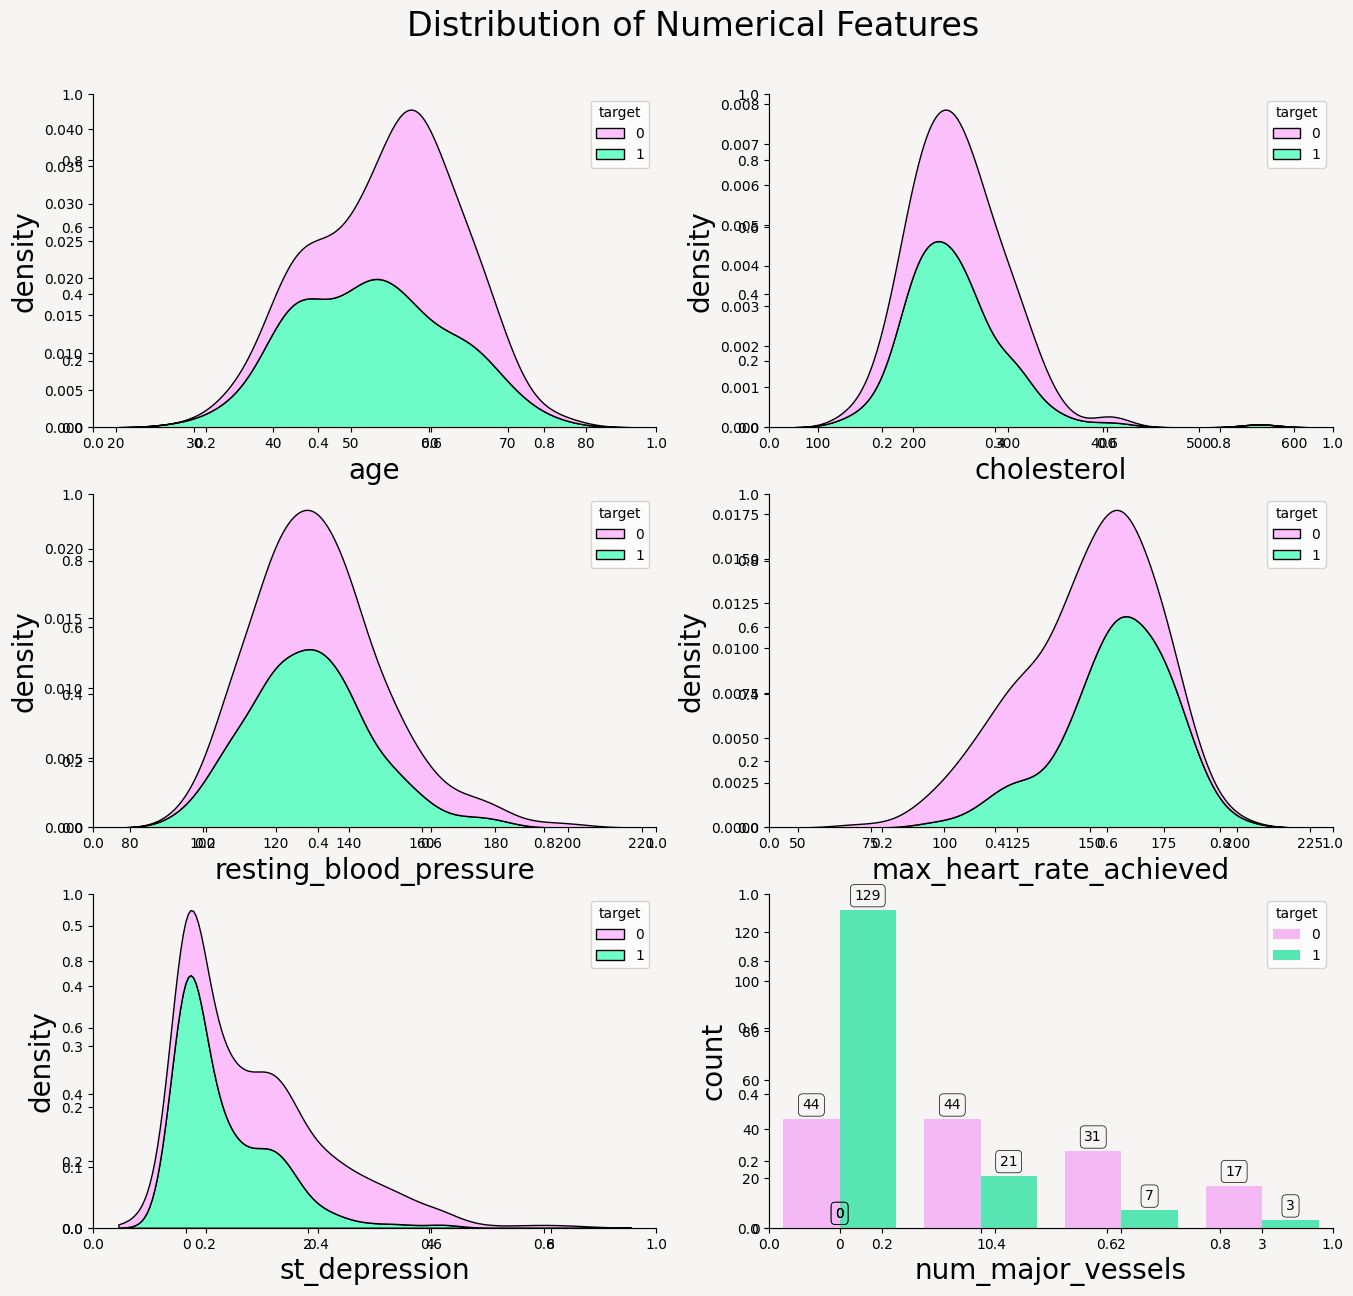

In [29]:


# ---------------------------------------------------------------
# STEP 1: HOW MANY PLOTS DO WE NEED? (ONE PER NUMERIC FEATURE)
# ---------------------------------------------------------------

# len(num_feats) counts how many column names are in the list 'num_feats'.
# Example: if num_feats = ['age','cholesterol',...,'num_major_vessels'] and has 6 items, L = 6.
L = len(num_feats)

# We want to lay out our subplots (small charts) in a grid with 2 columns.
# That means: each row will hold 2 small charts side-by-side.
ncol = 2

# We need enough rows to fit all L plots into a grid with 'ncol' columns.
# L / ncol = the exact (possibly fractional) number of rows we would need.
# np.ceil(...) "rounds up" to the next whole number, so we have enough rows.
# int(...) converts that rounded value to a plain integer (matplotlib expects integers).
# Example: if L=5 and ncol=2 → L/ncol=2.5 → ceil(2.5)=3 → we need nrow=3 rows.
nrow = int(np.ceil(L / ncol))

# (Optional) This would tell you how many empty cells you'd have in the last row.
# For example, with L=5 and a 3x2 grid, total cells=6, so one cell is unused.
# remove_last = (nrow * ncol) - L


# ---------------------------------------------------------------
# STEP 2: CREATE THE CANVAS (FIGURE) AND THE GRID (SUBPLOTS/AXES)
# ---------------------------------------------------------------

# plt.subplots(...) creates:
#   - 'fig': the big "canvas" that will hold all subplots
#   - 'ax' : a 2D array of "axes" objects (each axes is one small plotting area)
#
# nrow, ncol define how many small plots we want (a grid of nrow x ncol).
# figsize=(16,14) controls how big the whole figure is on screen (in inches).
# facecolor sets the background color of the big figure.
fig, ax = plt.subplots(nrow, ncol, figsize=(16, 14), facecolor='#F6F5F4')

# Adjust spacing inside the figure so a big title at the top won’t overlap plots.
# 'top=0.92' means: reserve a bit of space at the top for the title (8% of height).
fig.subplots_adjust(top=0.92)


# ---------------------------------------------------------------
# STEP 3: LOOP OVER EACH NUMERIC FEATURE AND DRAW ITS SUBPLOT
# ---------------------------------------------------------------

# We'll place plots into the grid using a 1-based index (matplotlib's pyplot API uses 1,2,3,...).
# i will start at 1 for the first subplot, then 2 for the next, etc.
i = 1

# Go through each column name in num_feats (e.g., 'age', 'cholesterol', ...)
for col in num_feats:
    # Select which cell in the grid we are about to draw in.
    # plt.subplot(rows, cols, index) says:
    #   "Activate the subplot at position 'index' in a rows x cols grid."
    # The 'index' counts left-to-right across rows, starting at 1.
    # facecolor sets the background color for THIS small plotting panel.
    plt.subplot(nrow, ncol, i, facecolor='#F6F5F4')

    # -----------------------------------------------------------
    # CHOICE OF PLOT TYPE:
    # For MOST numeric features, we show a KDE (smooth distribution curve).
    # For 'num_major_vessels' (which is a small integer count 0..3),
    # a bar chart (count plot) is more appropriate than a smooth curve.
    # -----------------------------------------------------------

    if col != 'num_major_vessels':
        # ---------- KDE PLOT FOR CONTINUOUS NUMERIC FEATURES ----------
        # sns.kdeplot draws a smooth curve that represents the distribution of values.
        # data=data : use the DataFrame named 'data'.
        # x=col     : plot the distribution of this column along the X-axis.
        # hue="target" : split the data by the 'target' column (e.g., 0 vs 1) and color them differently.
        # multiple="stack" : stack the colored areas so their heights add up (easier to compare).
        # palette=mypal[1::4] : choose a subset of colors from your custom palette.
        ax_cur = sns.kdeplot(
            data=data,
            x=col,
            hue="target",
            multiple="stack",
            palette=mypal[1::4]
        )

        # Set axis labels to make the plot readable.
        # X label = the feature name; Y label = "density" (KDE shows density, not raw counts).
        ax_cur.set_xlabel(col, fontsize=20)
        ax_cur.set_ylabel("density", fontsize=20)

        # Remove some border lines ("spines") around the plot for a cleaner style.
        # right=True removes the right border. The second call keeps defaults; it's harmless styling redundancy.
        sns.despine(right=True)
        sns.despine(offset=0, trim=False)

    else:
        # ---------- COUNT PLOT FOR DISCRETE COUNT FEATURE ----------
        # For 'num_major_vessels', values are 0,1,2,3; a bar chart shows counts clearly.
        # We capture the returned axes in 'ax_cur' so we can annotate bars on the SAME axes.
        ax_cur = sns.countplot(
            data=data,
            x=col,
            hue="target",
            palette=mypal[1::4]
        )

        # Label axes for the bar chart:
        ax_cur.set_xlabel(col, fontsize=20)
        ax_cur.set_ylabel("count", fontsize=20)

        # Optional: remove right spine for consistent style.
        sns.despine(right=True)

        # Annotate each bar with its height (the number of rows in that category and hue).
        # ax_cur.patches is the list of rectangles (bars) that were drawn.
        for p in ax_cur.patches:
            # p.get_height() is how tall the bar is (the count).
            height = p.get_height()

            # p.get_x() is the left edge of the bar; p.get_width() is the bar's width.
            # Adding half the width centers the text horizontally above the bar.
            # 'height + 3' places the text a little above the bar's top so it doesn't overlap.
            ax_cur.text(
                p.get_x() + p.get_width() / 2.0,  # X position (center of the bar)
                height + 3,                       # Y position (just above the bar)
                f'{height:.0f}',                  # The text: the integer count (no decimals)
                ha="center",                      # Horizontal alignment: center the text
                va="bottom",                      # Vertical alignment: text baseline sits on the y value
                bbox=dict(                        # Draw a small rounded box around the text for readability
                    facecolor='none',             # transparent background
                    edgecolor='black',            # thin black border
                    boxstyle='round',
                    linewidth=0.5
                )
            )

    # Move to the next subplot index for the next feature.
    i = i + 1

# ---------------------------------------------------------------
# STEP 4: BIG TITLE FOR THE WHOLE FIGURE
# ---------------------------------------------------------------

# plt.suptitle(...) adds a single, centered title above all subplots.
plt.suptitle('Distribution of Numerical Features', fontsize=24)


In [ ]:
data.head(20)

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,resting_electrocardiogram,max_heart_rate_achieved,exercise_induced_angina,st_depression,st_slope,num_major_vessels,thalassemia,target
0,63,male,asymptomatic,145,233,> 120 mg/dL,normal,150,no,2.3,upsloping,0,fixed defect,1
1,37,male,non-anginal pain,130,250,≤ 120 mg/dL,ST-T wave abnormality,187,no,3.5,upsloping,0,normal,1
2,41,female,atypical angina,130,204,≤ 120 mg/dL,normal,172,no,1.4,downsloping,0,normal,1
3,56,male,atypical angina,120,236,≤ 120 mg/dL,ST-T wave abnormality,178,no,0.8,downsloping,0,normal,1
4,57,female,typical angina,120,354,≤ 120 mg/dL,ST-T wave abnormality,163,yes,0.6,downsloping,0,normal,1
5,57,male,typical angina,140,192,≤ 120 mg/dL,ST-T wave abnormality,148,no,0.4,flat,0,fixed defect,1
6,56,female,atypical angina,140,294,≤ 120 mg/dL,normal,153,no,1.3,flat,0,normal,1
7,44,male,atypical angina,120,263,≤ 120 mg/dL,ST-T wave abnormality,173,no,0.0,downsloping,0,reversible defect,1
8,52,male,non-anginal pain,172,199,> 120 mg/dL,ST-T wave abnormality,162,no,0.5,downsloping,0,reversible defect,1
9,57,male,non-anginal pain,150,168,≤ 120 mg/dL,ST-T wave abnormality,174,no,1.6,downsloping,0,normal,1


# Pair-plots

Text(0.5, 0.98, 'Pairplot: Numerical Features')

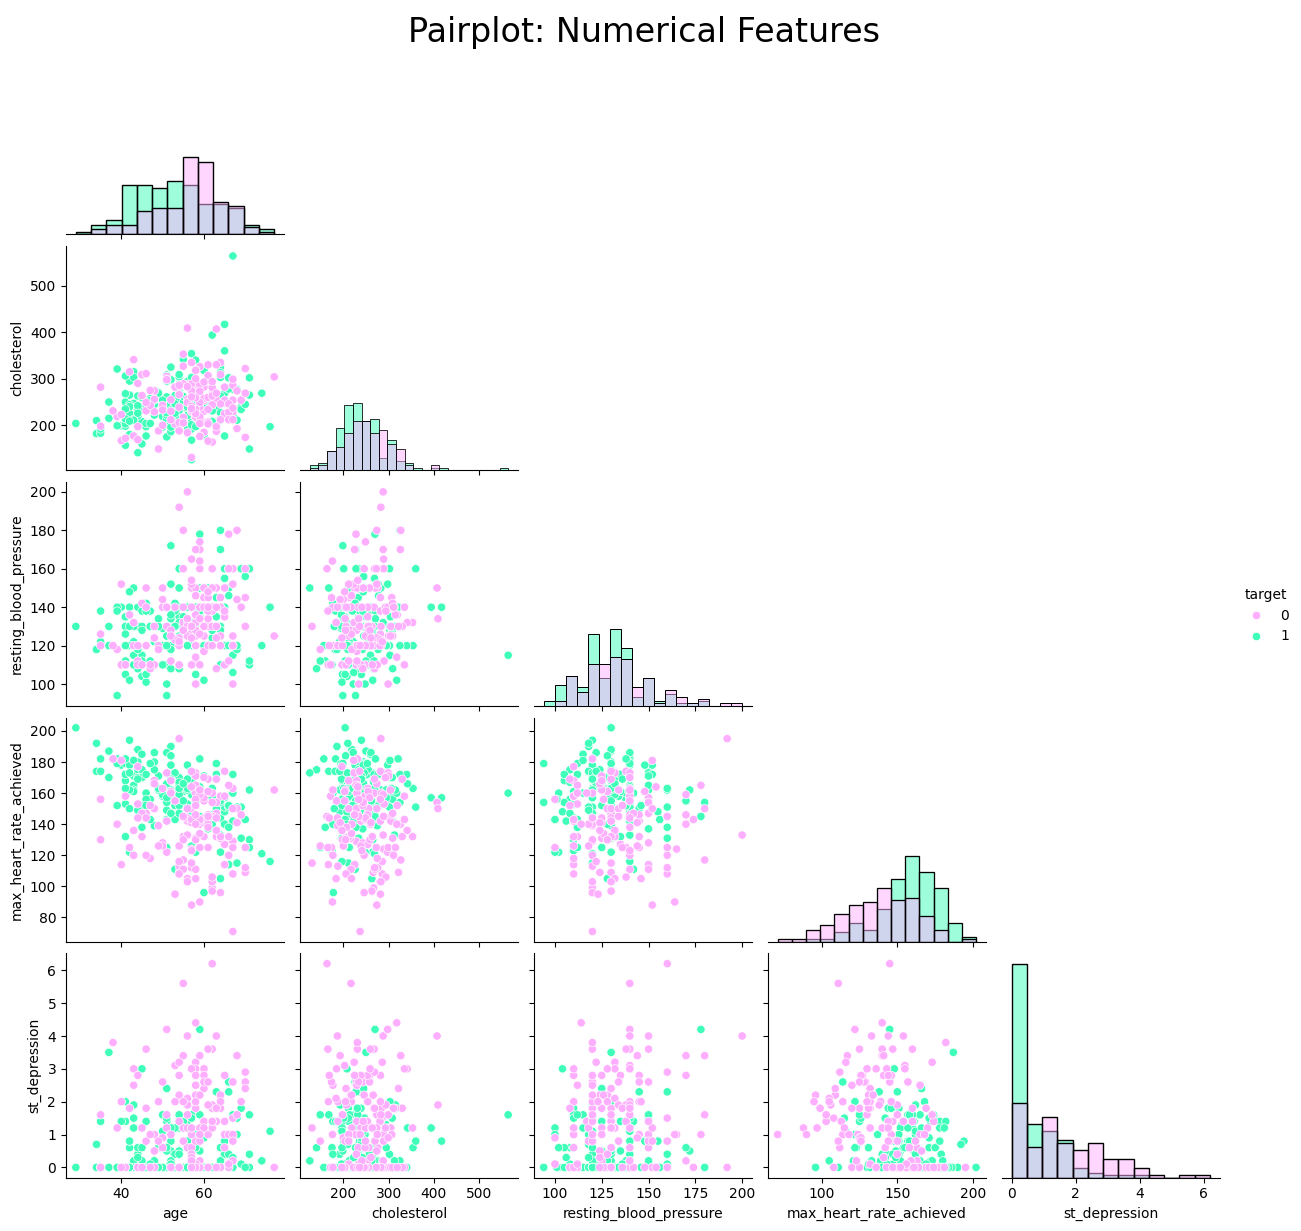

In [30]:
# We want to create a "pairplot" to visualize relationships between
# several numeric features, colored by the target class.

# 1) Create a Python LIST of column names we want to plot.
#    - A list is an ordered collection written with square brackets [ ... ].
#    - Each item here is a STRING (text) naming a column in your DataFrame.
#    - We now use a clear, descriptive variable name `selected_cols`
#      instead of "_" so it’s easier to read and won’t conflict with
#      Jupyter’s special meaning of "_" (last output).
selected_cols = ['age', 'cholesterol', 'resting_blood_pressure', 'max_heart_rate_achieved', 'st_depression', 'target']

# 2) Select only those columns from the big table `data`.
#    - In pandas, `data[ <list_of_column_names> ]` returns a new DataFrame that contains
#      exactly those columns, in that order.
#    - We store the result in `data_`. The trailing underscore is just part of the name;
#      it’s a common convention to avoid name clashes (e.g., with a function named `data`).
data_ = data[selected_cols]

# 3) Build the pairplot.
#    - `sns.pairplot(...)` draws a grid of plots:
#        * Each NUMERIC feature is plotted against every other feature (pairwise).
#        * Off-diagonal cells: scatter plots (x = one feature, y = the other).
#        * Diagonal cells: a 1D distribution plot for that feature (we chose 'hist').
#    - Arguments used here:
#        data_=data_        → (positional first argument) the DataFrame to visualize.
#                             Equivalent named form would be `data=data_`.
#        hue="target"       → color the points by the 'target' column (different class → different color).
#        corner=True        → draw only the LOWER triangle (avoids mirrored duplicates and saves space).
#        diag_kind='hist'   → on the diagonal, show HISTOGRAMS (binned counts) of each feature.
#        palette=mypal[1::4]→ choose a COLOR PALETTE using slicing on your palette list:
#                             * `mypal` is your list of color hex codes defined elsewhere.
#                             * `mypal[1::4]` means: start at index 1 (the 2nd color) and take every 4th
#                               color thereafter (indices 1, 5, 9, ...), yielding a subset of colors.
#    - Return value:
#        Seaborn returns a PairGrid object that owns the entire figure and all its axes.
#        We store it in `g` so we can adjust titles, spacing, etc., later if needed.
g = sns.pairplot(data_, hue="target", corner=True, diag_kind='hist', palette=mypal[1::4]);

#    NOTE on the semicolon at the end of the previous line:
#    - In Python, a semicolon is OPTIONAL. In Jupyter, ending a plotting call with `;`
#      suppresses the printed text output (like the object’s repr) so the cell looks cleaner.
#      It does NOT change the plot itself.

# 4) Add a big title above the entire figure.
#    - `plt.suptitle(...)` places a centered title at the top of the CURRENT figure.
#    - Because `pairplot` creates its own figure, `plt.suptitle` usually works,
#      but attaching the title directly to the PairGrid’s figure (`g.fig.suptitle(...)`)
#      is the most explicit/robust approach.
#    - fontsize=24 makes the title text larger.
plt.suptitle('Pairplot: Numerical Features', fontsize=24)

# (Optional, more robust alternative to set the title on the pairplot’s own figure:)
# g.fig.suptitle('Pairplot: Numerical Features', fontsize=24)
# g.fig.subplots_adjust(top=0.93)  # make room so the title doesn’t overlap the grid

#### Selected Features

#  What is a “reg-plot”? (Seaborn `regplot`)

A **regression plot** (often called a **reg-plot**) is a chart that shows:
1) your **data points** (scatter plot), and  
2) a **best-fit straight line** through those points (a simple linear regression line).  

It’s useful when you want to see whether two numeric variables have a **linear relationship** (do they move together in a way a straight line can summarize?).



## What the reg-plot draws

- **Scatter points**: each dot is one person/row in your dataset.  
- **Best-fit line**: the straight line that minimizes the average squared vertical distance from all points (ordinary least squares).  
- **Optional confidence band**: a shaded area around the line showing uncertainty (by default, Seaborn shows a 95% confidence interval).

> If the line slopes **upward**, the y-variable tends to **increase** as the x-variable increases (**positive** relationship).  
> If it slopes **downward**, the y-variable tends to **decrease** as x increases (**negative** relationship).  
> If it’s roughly **flat**, there’s little linear relationship.



## How this relates to your pair-plot

A **pair-plot** shows many scatter plots at once, pairing each feature with every other feature.  
Looking at the **first column** where **Age** is on the x-axis, you essentially get a set of “age vs feature” plots.  
A **reg-plot** for “feature vs Age” is like taking one of those scatter panels and adding the **best-fit line** on top to visualize the **linear trend**.





> **“Except maximum_heart_rate_achieved, the others are positively and linearly related with age (albeit a weaker relation with st_depression).”**

- Many clinical features such as **resting blood pressure** (and sometimes **cholesterol**, depending on the cohort and treatments) often show a **positive** trend with **Age**.  
- **st_depression** (also called *oldpeak*) may show only a **weak** relationship with Age; it’s influenced more by exercise-induced ischemia than by age alone.  
- **maximum_heart_rate_achieved** (often `thalach`) typically shows a **negative** trend with Age. As people get older, their maximum achievable heart rate usually declines.  
  - So it’s reasonable that this one does **not** share the same positive trend as the others.

> **“Younger patients with higher maximum_heart_rate_achieved are more likely to have a heart condition.”**

- This is **likely not correct** for typical heart-disease datasets.  
- Usually, **higher** maximum heart rate achieved is a sign of **better** exercise capacity, which often aligns with **lower** likelihood of disease, not higher.  
- What is commonly observed: **older** or **diseased** patients tend to have **lower** maximum heart rate achieved.

> **“Lower st_depression regardless of age is also likely an indication of a heart disease.”**

- This is also **likely not correct**.  
- Clinically, **higher** ST depression during stress testing is more concerning and can indicate ischemia.  
- So **higher** `st_depression` values are typically more associated with heart disease risk.



# How to read your reg-plots (simple checklist)

1. **Slope direction**  
   - Upward line → y increases with age (positive relation).  
   - Downward line → y decreases with age (negative relation).

2. **Strength of relation**  
   - Points tightly clustered around the line → stronger linear relation.  
   - Points widely scattered → weaker relation (line is less informative).

3. **Outliers and curvature**  
   - If there’s a curved pattern or a few extreme points, a straight line may be misleading. Consider non-linear fits or robust methods.

4. **Subgroups**  
   - If you color by `target` (e.g., class 0/1), check whether the groups occupy different regions. Group differences can create or mask overall trends.



# ⚠️ Important caveats

- **Correlation ≠ causation**: A line on a reg-plot shows association, not cause.  
- **Confounders**: Medication, fitness, or other factors may affect features and age simultaneously.  
- **Discrete variables**: For **counts with few unique values** (e.g., `num_major_vessels` = 0–3), a **count plot/bar chart** is more appropriate than a density or reg-plot.





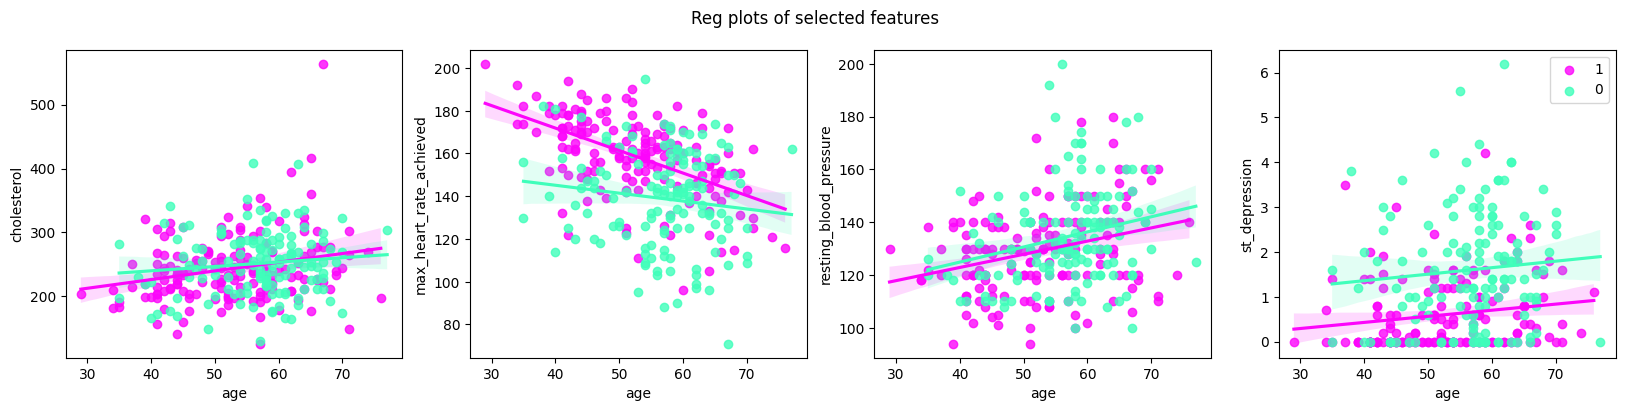

In [ ]:
# We want to draw four side-by-side regression plots (reg-plots). For each feature,
# we overlay two reg-plots on the SAME axes: one for target==1 and one for target==0,
# so we can compare the linear trend with age between the two groups.

# 1) Create a figure (the big canvas) and an array of 4 axes (the small plotting areas).
#    - plt.subplots(1, 4, ...) means "make a grid with 1 row and 4 columns" → 4 subplots in one row.
#    - figsize=(20, 4) sets the size of the entire figure in inches: 20 inches wide, 4 inches tall.
#    - 'fig' is the figure object; 'ax' is a NumPy array of 4 axes you can index as ax[0], ax[1], ax[2], ax[3].
fig, ax = plt.subplots(1,4, figsize=(20, 4))

# 2) Draw a regression plot (scatter points + best-fit line) for the first feature pair: age vs cholesterol.
#    - data=... : We pass a FILTERED DataFrame: data[data['target'] == 1]
#                 This keeps only the rows where the 'target' column equals 1 (e.g., disease present).
#                 In pandas, data[condition] returns rows where 'condition' is True.
#    - x='age' : Put 'age' on the x-axis.
#    - y='cholesterol' : Put 'cholesterol' on the y-axis.
#    - ax=ax[0] : Draw on the FIRST axes in our 4-panel row (the leftmost subplot).
#    - color=mypal[0] : Use the first color from your custom palette 'mypal' for target==1.
#    - label='1' : Set the legend label for these points/line to "1".
sns.regplot(data=data[data['target'] ==1], x='age', y='cholesterol', ax = ax[0], color=mypal[0], label='1')

# 3) Overlay the target==0 group on the SAME first axes (ax[0]).
#    - Same x and y, but now filter to data['target'] == 0 (e.g., no disease).
#    - Different color (mypal[5]) so the two groups are visually distinct.
#    - Label '0' so the legend can distinguish them.
sns.regplot(data=data[data['target'] ==0], x='age', y='cholesterol', ax = ax[0], color=mypal[5], label='0')

# 4) Second subplot (ax[1]): age vs max_heart_rate_achieved, target==1
sns.regplot(data=data[data['target'] ==1], x='age', y='max_heart_rate_achieved', ax = ax[1], color=mypal[0], label='1')

# 5) Overlay target==0 on the same second subplot (ax[1]):
sns.regplot(data=data[data['target'] ==0], x='age', y='max_heart_rate_achieved', ax = ax[1], color=mypal[5], label='0')

# 6) Third subplot (ax[2]): age vs resting_blood_pressure, target==1
sns.regplot(data=data[data['target'] ==1], x='age', y='resting_blood_pressure', ax = ax[2], color=mypal[0], label='1')

# 7) Overlay target==0 on the same third subplot (ax[2]):
sns.regplot(data=data[data['target'] ==0], x='age', y='resting_blood_pressure', ax = ax[2], color=mypal[5], label='0')

# 8) Fourth subplot (ax[3]): age vs st_depression, target==1
sns.regplot(data=data[data['target'] ==1], x='age', y='st_depression', ax = ax[3], color=mypal[0], label='1')

# 9) Overlay target==0 on the same fourth subplot (ax[3]):
sns.regplot(data=data[data['target'] ==0], x='age', y='st_depression', ax = ax[3], color=mypal[5], label='0')

# 10) Add a big, centered title for the entire figure (all four subplots together).
plt.suptitle('Reg plots of selected features')

# 11) Show a legend (the colored labels '1' and '0') on the CURRENT axes.
#     IMPORTANT: plt.legend() without arguments applies to the *current* axes only,
#     which is usually the LAST subplot you drew on (here, ax[3]).
#     So the legend will likely appear only on the fourth subplot.
#     If you want a legend on EVERY subplot, call ax[i].legend() for each i.
#     If you want ONE shared legend for the whole figure, use fig.legend(...) with handles/labels.
plt.legend();














In [31]:
data.head(20)

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,resting_electrocardiogram,max_heart_rate_achieved,exercise_induced_angina,st_depression,st_slope,num_major_vessels,thalassemia,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
5,57,1,0,140,192,0,1,148,0,0.4,1,0,1,1
6,56,0,1,140,294,0,0,153,0,1.3,1,0,2,1
7,44,1,1,120,263,0,1,173,0,0.0,2,0,3,1
8,52,1,2,172,199,1,1,162,0,0.5,2,0,3,1
9,57,1,2,150,168,0,1,174,0,1.6,2,0,2,1



### 1.3.3 Categorical Features

                                                                                                                                    
We use a count plot to visualize the different categories with respect to the target variable. Two things we could take note of are the distribution of each category in the dataset and their contribution to the probability of correct prediction of the target variable, i.e has disease (=1) or has no disease (=0). Below is the summary of the categorical features.

<blockquote style="margin-right:auto; margin-left:auto; color:white; background-color: #4e4e4e; padding: 1em; margin:24px;">
   
<ul>
<li> <font color="white" size=+1.0><b>Chest Pain:</b></font>
    <ul>
        <li> More than 75% of the patients experience either <strong><em>typical angina</em></strong> or <strong><em>non-angina</em></strong> chest pain.
        <li> Patients who experienced <em>atypical angina</em> or <strong>non-angina</strong> chest pain are more likely to have a heart disease.
    </ul>  
    
<li> <font color="white" size=+1.0><b>Resting Electrocardiogram:</b></font>
    <ul>
        <li> Patients with <strong>Left ventricular hypertrophy</strong> are the fewest (~1.4%). The rest is almost a 50-50 split between patients with <strong>ST-T abnormality</strong> and those with normal REC tests.
        <li> <strong>ST-T abnormality</strong>  seem to have a better correlation with the target, i.e the majority of patients with this kind of REC test ended up with a heart disease.
</ul>    
<li> <font color="white" size=+1.0><b>ST-Slope:</b></font>
    <ul>
    <li> Most patients have a <strong>downsloping</strong> or <strong>flat</strong> ST-Slope of their REC test.
    <li> <strong>downsloping</strong> ST-Slopes are a strong indication that a patient might have a heart disease.
</ul>   
    
<li> <font color="white" size=+1.0><b>Thalassemia:</b></font>
    <ul>
    <li> Most patients have a <strong>normal</strong> or <strong>reversable defect</strong>
    <li> Patients who have thalassemia defects (reversable + fixed) are less likely to have a heart disease. Whereas, those with normal thalassemia are more likely to have a heart condition. Sounds not intuitive.
</ul>   
    
<li> <font color="white" size=+1.0><b>Fasting blood sugar</b></font>
    <ul>
    <li> Patients with lower (less than 120mg/ml) <strong>fasting blood sugar</strong> are the majority in our dataset consisting of ~85% of the sample.
    <li> Having lower resting blood sugar tends to increase the chances (~54%) of a heart disease.
</ul>   
    
<li> <font color="white" size=+1.0><b>Exercise Induced Angina</b></font>
    <ul>
    <li> Two-third of the patients showed no exercise induced angina.
    <li> 76% of the patients with exercise induced angina had no heart conditions. Whereas ~69% of the patients who did not experience exercise induced angina were diagnosed with heart condition.
</ul>
    
<li> <font color="white" size=+1.0><b>Sex</b></font>
    <ul>
    <li> More patients in the sample data are male.
    <li> Females seem to suffer from heart condition more than males.
</ul>   
    
</ul>                                                                                                                                             
</blockquote>




<!-- def cat_freq_counter(df, columns):
    dataFrames_ = []
    for col in columns:
        dataFrames_.append(pd.DataFrame(df[col].value_counts()).style.background_gradient(cmap='cool'))
    return HTML(f"<table><tr> {''.join(['<td>' + dfs._repr_html_() + '</td>' for dfs in dataFrames_])} </tr></table>")

# split the width of the output
display(cat_freq_counter(data, cat_feats[0:4]))
display(cat_freq_counter(data, cat_feats[4:])) -->

#### Distribution: Count plots

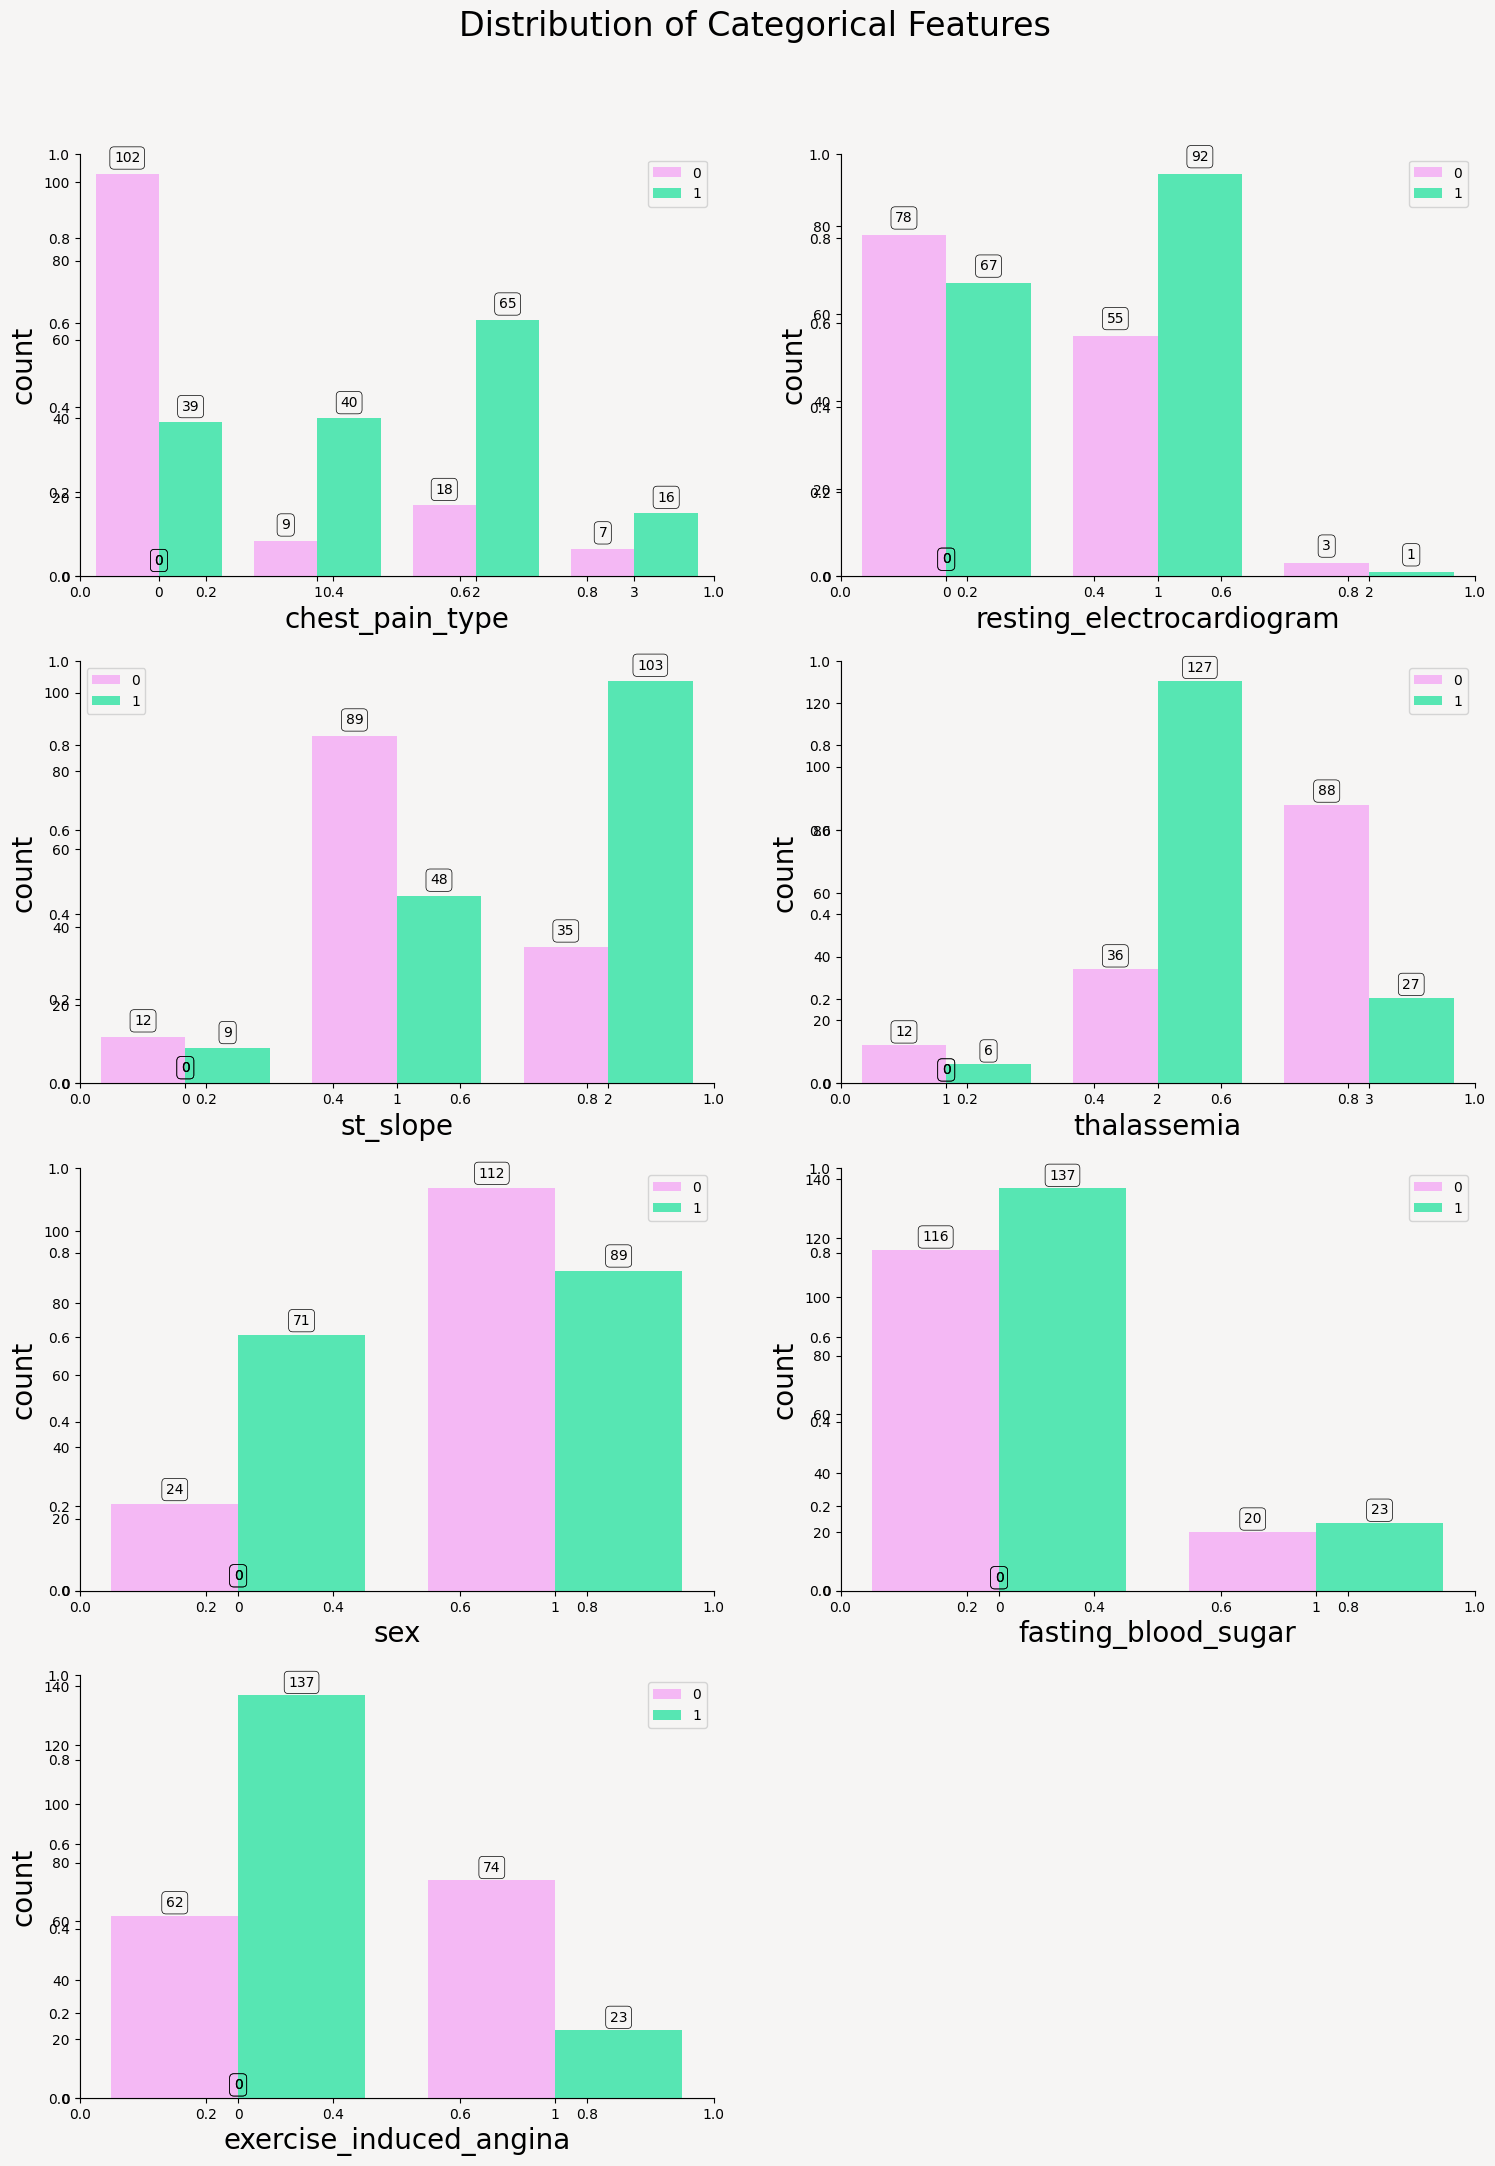

In [32]:
# ===================================================================
# FUNCTION: count_plot
# ===================================================================
# GOAL (plain English):
#   Make a grid of bar charts. Each chart shows how often each CATEGORY
#   appears in a column, and the bars are split/colored by the 'target'
#   (for example, 0 vs 1). This lets you compare class makeup inside
#   each category and spot imbalances or rare categories.
#
# WHAT YOU NEED TO KNOW FIRST:
# - "data" is a pandas DataFrame (like a spreadsheet in code).
# - "cat_feats" is a Python LIST of column names that are categorical.
# - We’ll compute how many charts we need, build a grid, and then fill
#   each grid cell with a seaborn countplot for one categorical column.
# ===================================================================

def count_plot(data, cat_feats):

    # -------------------------------------------
    # 1) HOW MANY PLOTS (PANELS) WILL WE DRAW?
    # -------------------------------------------
    # len(cat_feats) counts how many items are in the list cat_feats.
    # Example: if cat_feats = ['sex','cp','thal'] then L = 3
    L = len(cat_feats)

    # We want to lay the small charts in a grid with 2 columns (side by side).
    # That means each row will contain 2 charts.
    ncol = 2

    # We need enough rows to fit all L charts, given 2 columns per row.
    # L / ncol is the "exact" number of rows (can be fractional).
    # np.ceil(...) means "round UP" to the next whole number so we have enough rows.
    # int(...) converts it to an integer because matplotlib expects integers.
    # Example: L=5, ncol=2 → L/ncol = 2.5 → ceil(2.5)=3 → nrow=3
    nrow = int(np.ceil(L / ncol))

    # How many empty cells does our nrow x ncol grid have AFTER placing L plots?
    # Total cells = nrow * ncol. If that is larger than L, we have empty spots.
    # Example: nrow*ncol = 6 but L = 5 → remove_last = 1 empty cell.
    remove_last = (nrow * ncol) - L

    # -------------------------------------------
    # 2) CREATE THE FIGURE AND THE GRID OF AXES
    # -------------------------------------------
    # plt.subplots(rows, cols, ...) returns:
    #   - fig: the big "canvas" that holds everything
    #   - ax : a 2D array (nrow x ncol) of "axes" (each axes is one small chart area)
    # figsize=(18, 24) sets the overall size in inches (width=18, height=24).
    # facecolor sets the background color of the big figure.
    fig, ax = plt.subplots(nrow, ncol, figsize=(18, 24), facecolor='#F6F5F4')

    # Make a little extra space at the top for a large title we’ll add later.
    # top=0.92 means the top inner boundary is at 92% of the figure height,
    # leaving ~8% for the title region.
    fig.subplots_adjust(top=0.92)

    # We’ll hide one empty subplot if the grid has extra cells.
    # ax is a 2D array; ax.flat flattens it to a 1D sequence so we can index
    # across all cells easily.
    # ax.flat[-remove_last] means: "go to the element that is 'remove_last' from the end".
    # Example: if remove_last=1 → ax.flat[-1] (the very last axes).
    #
    # set_visible(False) tells matplotlib not to draw that axes at all.
    #
    # IMPORTANT PITFALL:
    # If remove_last == 0 (meaning the grid is perfectly filled),
    # then -remove_last == 0, and this would hide ax.flat[0] (the FIRST subplot),
    # which you probably don't want. A safe pattern is:
    #     if remove_last > 0: ax.flat[-remove_last].set_visible(False)
    # We keep the original line to match your code but added this note.
    ax.flat[-remove_last].set_visible(False)

    # -------------------------------------------
    # 3) FILL EACH GRID CELL WITH A COUNTPLOT
    # -------------------------------------------
    # We'll place plots using matplotlib's pyplot indexing which starts at 1.
    # i = 1 means "first cell", i = 2 means "second cell", etc.
    i = 1

    # Loop over each categorical column name in the list
    for col in cat_feats:
        # Select which grid cell to draw into now.
        # plt.subplot(nrow, ncol, i) activates the i-th subplot in a grid of nrow x ncol.
        # facecolor sets the background for THIS small panel.
        plt.subplot(nrow, ncol, i, facecolor='#F6F5F4')

        # Draw a bar chart of category counts for this column (one bar per category).
        # hue="target" splits each bar by target class (e.g., 0 vs 1) using different colors,
        # so you can compare the class composition inside each category.
        #
        # palette=mypal[1::4] is list slicing on your custom color list:
        #   start at index 1 (the 2nd color) and take every 4th color thereafter.
        #   This picks a spaced-out subset of your palette.
        ax = sns.countplot(data=data, x=col, hue="target", palette=mypal[1::4])

        # Label the axes so the reader knows what they’re looking at.
        ax.set_xlabel(col, fontsize=20)     # x-axis label is the column name
        ax.set_ylabel("count", fontsize=20) # y-axis label shows that bar heights are counts

        # Style tweak: remove the right border line ("spine") for a cleaner look.
        sns.despine(right=True)
        # Another style call; offset/trim control how spines are adjusted.
        # Leaving them as defaults is fine; this is just for visual polish.
        sns.despine(offset=0, trim=False)

        # Add a legend so viewers know which color corresponds to which 'target' class.
        # facecolor matches the legend box to the figure's light background.
        plt.legend(facecolor='#F6F5F4')

        # ---------- ANNOTATE BAR HEIGHTS (exact counts) ----------
        # ax.patches is a list of the rectangular bar objects drawn by seaborn.
        for p in ax.patches:
            height = p.get_height()  # the number of rows represented by this bar (its height)

            # Place a text label centered above the bar.
            # p.get_x() is the left x-position of the bar; p.get_width() is its width.
            # Adding half the width centers the text horizontally.
            # height + 3 sets the text slightly above the bar top so it's not on the edge.
            # '{:1.0f}'.format(height) formats the number with 0 decimals (integer).
            ax.text(
                p.get_x() + p.get_width() / 2.,
                height + 3,
                '{:1.0f}'.format(height),
                ha="center",                # center horizontally
                bbox=dict(                  # draw a small rounded border around the text
                    facecolor='none',       # transparent fill
                    edgecolor='black',      # thin black outline
                    boxstyle='round',
                    linewidth=0.5
                )
            )

        # Move to the next subplot index so the next feature goes into the next cell.
        i = i + 1

    # -------------------------------------------
    # 4) ADD A BIG TITLE OVER THE WHOLE FIGURE
    # -------------------------------------------
    plt.suptitle('Distribution of Categorical Features', fontsize=24)

    # The function’s "result" is the drawn figure on screen; returning 0 is just a placeholder.
    return 0

# ---------------------------------------------------------------
# WHY MAKE THESE PLOTS? (the reasoning)
# ---------------------------------------------------------------
# • Quick overview of each categorical feature:
#   You immediately see which categories are common, rare, or possibly mistyped.
#
# • Class comparison by category:
#   Because we color by 'target', you can check whether certain categories are
#   associated with target==1 more often than target==0 (or vice versa).
#
# • Data quality checks:
#   Bars with tiny counts might be noise or might need grouping.
#   Surprising categories can reveal data-entry issues.
#
# • Modeling prep:
#   Helps decide how to encode categories (e.g., one-hot), whether to combine rare
#   levels, or whether class imbalance might affect your model.
# ---------------------------------------------------------------

# ---------------------------------------------------------------
# CALL THE FUNCTION
# ---------------------------------------------------------------
# cat_feats[0:-1] is Python list slicing.
# • start at index 0 (the first element),
# • go up to but NOT including the last element.
# In other words, "everything except the final item in cat_feats".
# This is often used to exclude 'target' if someone accidentally included it,
# or to skip a specific last categorical column.
count_plot(data, cat_feats[0:-1]);


In [33]:
# def count_plot(data, cat_feats):
#     L = len(cat_feats)
#     ncol= 2
#     nrow= int(np.ceil(L/ncol))
#     remove_last= (nrow * ncol) - L

#     fig, ax = plt.subplots(nrow, ncol,figsize=(18, 24), facecolor='#F6F5F4')
#     fig.subplots_adjust(top=0.92)
#     ax.flat[-remove_last].set_visible(False)

#     i = 1
#     for col in cat_feats:
#         plt.subplot(nrow, ncol, i, facecolor='#F6F5F4')
#         ax = sns.countplot(data=data, x=col, hue="target", palette=mypal[1::4])
#         ax.set_xlabel(col, fontsize=20)
#         ax.set_ylabel("count", fontsize=20)
#         sns.despine(right=True)
#         sns.despine(offset=0, trim=False)
#         plt.legend(facecolor='#F6F5F4')

#         for p in ax.patches:
#             height = p.get_height()
#             ax.text(p.get_x()+p.get_width()/2.,height + 3,'{:1.0f}'.format((height)),ha="center",
#                   bbox=dict(facecolor='none', edgecolor='black', boxstyle='round', linewidth=0.5))

#         i = i +1

#     plt.suptitle('Distribution of Categorical Features' ,fontsize = 24)
#     return 0

# count_plot(data, cat_feats[0:-1]);

##  Correlation Heatmaps <a class="anchor" id="1.4"></a>

A **correlation heatmap** is a color-coded table that shows **how strongly pairs of variables move together**.  
Each cell contains a number (the **correlation coefficient**) and a color:

- Values near **+1** → when one goes up, the other tends to go up too (strong positive relationship).  
- Values near **0** → little to no linear relationship.  
- Values near **−1** → when one goes up, the other tends to go down (strong negative relationship).

> Correlation shows **association**, not **cause**.



### Picking the right correlation for your data

Different variable types need different correlation measures:

| Pair type                        | Good choice                     | Notes |
|----------------------------------|----------------------------------|-------|
| numeric ↔ numeric                | **Pearson** (or **Spearman**)    | Pearson measures straight-line (linear) relationships. Spearman measures monotonic ranks. |
| binary (0/1) ↔ numeric           | **Point-biserial**               | Equivalent to Pearson if the binary is coded 0/1. |
| binary ↔ binary                  | **Phi** (φ)                      | Equivalent to Pearson on two 0/1 variables. |
| categorical (3+ labels) ↔ categorical (3+ labels) | **Cramér’s V**             | Uses a contingency table (counts). |
| ordinal ↔ ordinal                | **Spearman** or **Kendall τ**    | These use ranks and respect order. |

If you only compute **Pearson** on everything, you’ll get misleading numbers for pure categorical pairs.



###  Pearson’s correlation (numeric ↔ numeric)

**What it measures:**  
How well a **straight line** describes the relationship between two numeric variables.

**Range:** −1 to +1.  
- `+1` = perfect increasing line  
- `0`  = no linear relation  
- `−1` = perfect decreasing line


It is the **covariance** divided by the product of the **standard deviations**, which keeps the result between −1 and +1.

**Assumptions (when Pearson is most honest):**
- Both variables are numeric and roughly **linearly** related.
- No extreme outliers that dominate the line.
- Relationship is not curved. If it looks curved, use Spearman or transform the data.








Correlation heatmap is a useful tool to graphyically represent how two features are related to eachother. Depending upon the data types of the features, we need to use the appropriate correlation coefficient calculation methods. Examples are pearson's correlation coefficient, point biserial correlation, cramers'V correlation and etc.



* The Pearson correlation coefficient ― is a measure of linear correlation between two sets of data. It is the ratio between the covariance of two variables and the product of their standard deviations; thus it is essentially a normalised measurement of the covariance, such that the result always has a value between −1 and 1. ([ref. ](https://en.wikipedia.org/wiki/Pearson_correlation_coefficient))

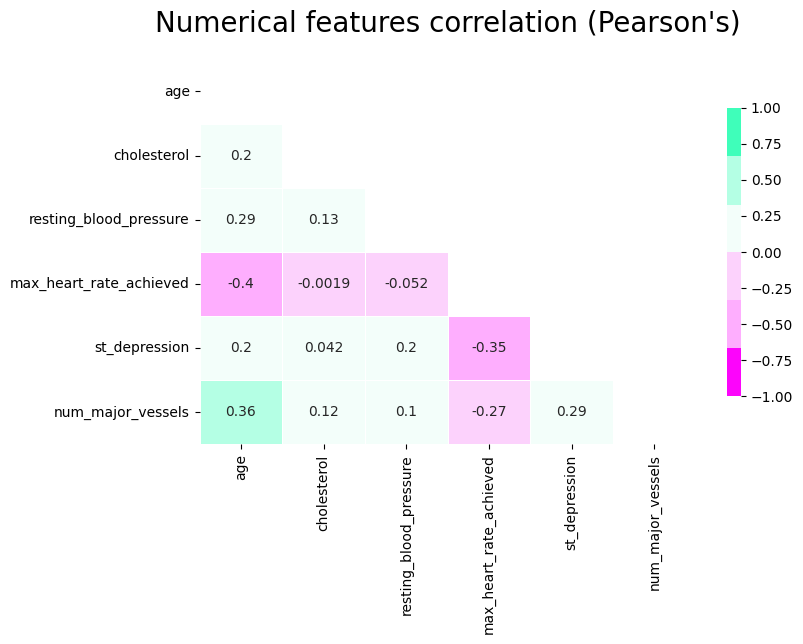

In [ ]:
# ---------------------------------------------------------------
# Compute a Pearson correlation matrix for numeric columns,
#       then draw a clean heatmap showing only the lower triangle.

# 1) Select ONLY the numeric columns we want to correlate.
#    - data is your full DataFrame.
#    - num_feats is a Python LIST of column names (strings) for numeric features.
#    - data[num_feats] returns a NEW, smaller DataFrame with just those columns, in that order.
df_ = data[num_feats]

# 2) Compute the correlation table (matrix) using Pearson’s method.
#    - .corr(method='pearson') calculates pairwise linear correlations between all columns in df_.
#    - The result is a square DataFrame: rows = features, columns = features.
#    - Each cell is a number between -1 and +1 (negative = opposite direction, positive = same direction).
corr = df_.corr(method='pearson')

# 3) Build a boolean MASK to hide the UPPER triangle of the heatmap.
#    Why? Correlation matrices are symmetric (A↔B = B↔A), so the upper half duplicates the lower half.
#    - np.ones_like(corr, dtype=bool) creates an array of True values with the SAME SHAPE as corr.
#    - np.triu(...) keeps only the UPPER triangular part of that array (including the diagonal).
#    - Result: 'mask' is a boolean array where True marks cells we want to HIDE in the plot.
mask = np.triu(np.ones_like(corr, dtype=bool))

# 4) Make a new figure and axes (the canvas and the plotting area).
#    - plt.subplots(...) returns:
#         f  : the Figure (whole canvas),
#         ax : the Axes (where the heatmap will be drawn).
#    - figsize=(8, 5) sets width=8 inches, height=5 inches.
#    - facecolor=None means use the default figure background color.
f, ax = plt.subplots(figsize=(8, 5), facecolor=None)

# 5) Create a colormap (continuous gradient of colors) from your custom palette.
#    - sns.color_palette(mypal, as_cmap=True) turns your list of colors 'mypal'
#      into a continuous colormap object that the heatmap can use.
#    - If mypal is a list like ['#aabbcc', '#ddeeff', ...], this blends them into a gradient.
cmap = sns.color_palette(mypal, as_cmap=True)

# 6) Draw the heatmap.
#    - sns.heatmap(data, ...) takes a 2D table of numbers and displays them as colored cells.
#    - corr        : the correlation matrix to plot.
#    - mask=mask   : hides cells where mask==True (we hid the upper triangle to avoid duplicates).
#    - cmap=cmap   : which colors to use (the colormap defined above).
#    - vmax=1.0    : map correlation value +1.0 to the top of the color scale (strong positive).
#    - vmin=-1.0   : map correlation value -1.0 to the bottom of the color scale (strong negative).
#    - center=0    : color at 0 correlation sits in the middle of the color scale (neutral color).
#    - annot=True  : write the correlation numbers inside each visible cell.
#    - square=False: cell shape is rectangular (set True for perfect squares).
#    - linewidths=.5: thin lines between cells for readability.
#    - cbar_kws={"shrink": 0.75} : shrink the color bar (legend) to 75% size so it fits nicely.
sns.heatmap(
    corr,
    mask=mask,
    cmap=cmap,
    vmax=1.0, vmin=-1.0, center=0,
    annot=True,
    square=False,
    linewidths=.5,
    cbar_kws={"shrink": 0.75}
)

# 7) Add a title to the axes (the heatmap).
#    - set_title("text", fontsize=..., y=...) sets the title string and style.
#    - fontsize=20 makes the text larger.
#    - y=1.05 nudges the title slightly ABOVE the axes so it doesn’t overlap the top edge.
#    - The trailing semicolon ';' suppresses extra output in some notebook setups (purely cosmetic).
ax.set_title("Numerical features correlation (Pearson's)", fontsize=20, y=1.05);


In [ ]:
# df_ = data[num_feats]
# corr = df_.corr(method='pearson')
# mask = np.triu(np.ones_like(corr, dtype=bool))
# f, ax = plt.subplots(figsize=(8, 5), facecolor=None)
# cmap = sns.color_palette(mypal, as_cmap=True)
# sns.heatmap(corr, mask=mask, cmap=cmap, vmax=1.0, vmin=-1.0, center=0, annot=True,
#             square=False, linewidths=.5, cbar_kws={"shrink": 0.75})
# ax.set_title("Numerical features correlation (Pearson's)", fontsize=20, y= 1.05);

#  Point–Biserial Correlation

**What it is :**  
Point–biserial correlation tells you **how strongly** and **in which direction** a **numeric (continuous)** variable is related to a **binary (two-category)** variable.

- Example: Is **resting_blood_pressure** higher (on average) in patients with **target = 1** than **target = 0**?
- It’s a **special case of Pearson’s correlation** where one variable is truly **dichotomous** (only two values).



## When should I use it?

Use point–biserial when you have:
- One **continuous** variable (e.g., age, cholesterol).
- One **binary** variable (e.g., sex = female/male, target = 0/1).

> If the “binary” variable is text like `"yes"/"no"`, convert it to **0/1** first.


## What does the sign and size mean?

- **Sign (+/−)**  
  - **Positive**: the continuous variable tends to be **higher** for the group coded **1** than for the group coded **0**.  
  - **Negative**: the continuous variable tends to be **lower** for the group coded **1** than for the group coded **0**.

- **Magnitude (|r|)**  
  - **0.00–0.19**: very weak  
  - **0.20–0.39**: weak  
  - **0.40–0.59**: moderate  
  - **0.60–0.79**: strong  
  - **0.80–1.00**: very strong  
  *(rules of thumb; context matters)*

> **Correlation ≠ causation.** A high |r| means association, not “A causes B.”



## why it works

It compares the **means of the continuous variable** between the two groups (0 vs 1), then scales by the **overall spread** (standard deviation) and the **group proportions**.  
If group 1 has much higher values than group 0, you’ll get a **positive** number (and vice versa).





> If you run **Pearson’s r** on a 0/1-coded binary column and a numeric column, you get the **same value** as the point–biserial correlation.



## Assumptions (when it’s most reliable)

- The **continuous** variable is roughly **normally distributed** **within each group** (0 and 1).  
- The relationship is **linear** (mean difference summarizes it well).  
- No extreme outliers dominating the mean and standard deviation.  
- The binary variable is truly **dichotomous** (exactly two categories).

> If assumptions are shaky, still report r but verify with a **boxplot** or **violin plot**, and consider a **nonparametric** check too.





# Point–Biserial Correlation cont'd

 We want **one number** that tells us if a **number column** (like cholesterol) is different between two **groups** (like target = 0 vs 1).

- One column is **numeric**: e.g., cholesterol = 180, 220, 195 …
- The other column is **binary** (two groups): e.g., target = 0 or 1

Point–biserial correlation gives a value between **−1 and +1**:

- **Positive (+)** → the numeric values tend to be **higher** in the group coded **1** than in group 0  
- **Negative (−)** → the numeric values tend to be **lower** in group **1** than in group 0  
- **Near 0** → the two groups have **similar** numeric values (no clear difference)

That’s it. It’s just “**who tends to be higher** and **by how much**,” turned into a single standardized number.





Imagine two boxes of numbers:

- Box A = people with **target = 0**  
- Box B = people with **target = 1**

If the numbers in **Box B** are, on average, **bigger** than Box A, the correlation is **positive**.  
If Box B is, on average, **smaller**, the correlation is **negative**.  
If both boxes look about the **same**, it’s near **zero**.



## Mini example

Say we have cholesterol and target:

| person | cholesterol | target |
|-------:|------------:|:------:|
|   1    |     200     |   0    |
|   2    |     210     |   0    |
|   3    |     240     |   1    |
|   4    |     230     |   1    |

- Group **0** average = (200 + 210) / 2 = **205**  
- Group **1** average = (240 + 230) / 2 = **235**

Group 1’s average is **higher** → the point–biserial will be **positive**.  
If we swapped the numbers (group 1 lower), it would be **negative**.  
If both groups had similar averages, it would be near **0**.



## Why the number is between −1 and +1 (idea, not math)

We compare the **difference of group means** to the **overall spread** of the numbers.  
We also account for **how many** are in each group.  
This “standardizing” keeps the result in the **−1 to +1** range.



## What do I do in practice?

1) Make sure your binary column is **0/1** (e.g., `{'no':0, 'yes':1}`).  
2) Use the ready-made function to compute it.  
3) Read the **sign** and the **size**:

- Sign tells **which group (1 or 0)** tends to be **higher**
- Size (how far from 0) tells **how strong** the difference is






- A point-biserial correlation is used to measure the strength and direction of the association that exists between **one continuous variable and one dichotomous variable**. It is a special case of the Pearson’s product-moment correlation, which is applied when you have two continuous variables, whereas in this case one of the variables is measured on a dichotomous scale [[ref. ](https://statistics.laerd.com/spss-tutorials/point-biserial-correlation-using-spss-statistics.php)].

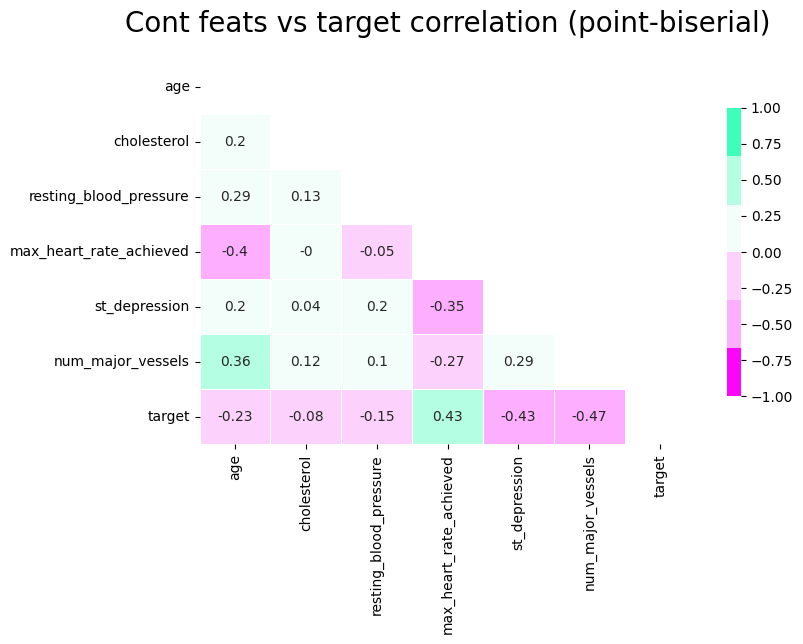

In [ ]:
# --------------------------------------------------------------------
# GOAL (what these plots are for)
# --------------------------------------------------------------------
# We want to visualize how strongly each CONTINUOUS feature is associated
# with the BINARY outcome 'target' using the POINT–BISERIAL correlation.
#
# Why point–biserial?
# - It is the correct correlation when ONE variable is numeric (continuous)
#   and the OTHER variable is binary (0/1). Here: feature ↔ target.
#
# What the heatmap shows:
# - A color-coded matrix of point–biserial correlations.
# - Values near +1 → the feature tends to be HIGHER when target=1 than when target=0.
# - Values near  0 → little/no linear difference between target groups.
# - Values near −1 → the feature tends to be LOWER when target=1 than when target=0.
#
# Important note about correctness:
# - pointbiserialr(x, y) is MEANINGFUL when one of (x, y) is binary and the other is continuous.
# - This code computes point–biserial for ALL PAIRS in feats_, including
#   continuous↔continuous and binary↔binary. Those off-diagonal values are not
#   standard point–biserial use. The most interpretable cells are the ones
#   where one side is 'target' (binary) and the other is a continuous feature.
#   You can read the full matrix, but focus your interpretation on the
#   feature↔target rows/columns.
#
# PRE-REQS:
# - Ensure `target` is numeric 0/1 (if it's text, map to 0/1 first).
# - Make sure you've imported:
#     import numpy as np
#     import pandas as pd
#     import seaborn as sns
#     import matplotlib.pyplot as plt
#     from scipy import stats
# - Make sure `mypal` is a list of color hex codes (your palette).
# - Make sure `data` contains the columns listed in feats_.


# --------------------------------------------------------------------
# 1) List of features we will include in the matrix
#    - A plain Python LIST of strings (column names) to include in the correlation grid.
#    - We include 'target' so we get the feature↔target correlations in the table.
#    - The other items should be continuous numeric columns.
# --------------------------------------------------------------------
feats_ = ['age', 'cholesterol', 'resting_blood_pressure', 'max_heart_rate_achieved',
          'st_depression', 'num_major_vessels', 'target']

# --------------------------------------------------------------------
# 2) Helper function to compute the point–biserial correlation
#    - This wraps scipy.stats.pointbiserialr for clarity.
#    - x, y are pandas Series (1D arrays of values from the DataFrame).
#    - stats.pointbiserialr returns a tuple: (r, p_value).
#      • r = correlation coefficient in [-1, 1]
#      • p_value = significance of the observed r under null hypothesis
#    - We only return r (the coefficient), because the heatmap displays effect size, not p-values.
# --------------------------------------------------------------------
def point_biserial(x, y):
    pb = stats.pointbiserialr(x, y)  # call the SciPy function on the two series
    return pb[0]                     # pb[0] extracts the correlation coefficient (float)

# --------------------------------------------------------------------
# 3) Build the full correlation table row by row
#    - Initialize an empty list `rows` that will become a matrix (list of lists).
#    - Outer loop: pick one feature name `x` at a time (row header).
#    - Inner loop: pair `x` with every feature name `y` (column header).
#    - For each (x, y), compute r = point_biserial(data[x], data[y]).
#      NOTE: The most meaningful cells are those with (feature, target) or (target, feature).
#    - round(r, 2) keeps the display tidy to 2 decimal places.
# --------------------------------------------------------------------
rows = []                     # will hold each row of the matrix (nested lists)
for x in feats_:              # loop over rows (x is a column name string)
    col = []                  # start a new row (list) to hold r-values for this x vs all y
    for y in feats_:          # loop over columns (y is a column name string)
        # data[x] selects a pandas Series (the column named x); likewise for data[y].
        # point_biserial computes r (may be non-standard if neither is binary).
        pbs = point_biserial(data[x], data[y])
        # round(pbs, 2) produces a nicely formatted number (e.g., 0.37) for the heatmap annotations.
        col.append(round(pbs, 2))
    rows.append(col)          # add the completed row to the rows matrix

# --------------------------------------------------------------------
# 4) Convert the nested Python lists to a NumPy array, then to a DataFrame
#    - np.array(rows) turns the list-of-lists into a numeric 2D array (matrix).
#    - pd.DataFrame(...) wraps it with row/column labels for easier reading.
#    - columns=... and index=... ensure the labels match feats_ order.
# --------------------------------------------------------------------
pbs_results = np.array(rows)
DF = pd.DataFrame(pbs_results,
                  columns=data[feats_].columns,  # same labels as in data for consistency
                  index=data[feats_].columns)

# --------------------------------------------------------------------
# 5) Build a mask to hide the UPPER HALF of the symmetric matrix
#    - Many correlation matrices are symmetric: r(x,y) == r(y,x).
#    - We create a boolean mask where True marks cells to HIDE in the plot.
#    - np.ones_like(DF, dtype=bool) creates an all-True array the same shape as DF.
#    - np.triu(...) keeps the "upper triangle" (on/above main diagonal) as True.
#    - DF.mask(mask) replaces those True cells with NaN so seaborn won’t draw them.
#    - Side note: "upper triangle" refers to which half of the square matrix,
#      not the shape of the individual cells (they remain square).
# --------------------------------------------------------------------
mask = np.triu(np.ones_like(DF, dtype=bool))  # True for upper half (incl. diagonal)

# Optionally set values above diagonal to NaN, which the heatmap won’t draw.
# This leaves only the lower half visible (no duplicate info).
corr = DF.mask(mask)

# --------------------------------------------------------------------
# 6) Create the figure and axes (the plotting canvas)
#    - plt.subplots(...) returns:
#        f  : a Figure object (the whole canvas)
#        ax : an Axes object (the specific area where we’ll draw the heatmap)
#    - figsize=(8, 5) sets width=8 inches and height=5 inches.
#    - facecolor=None uses the default background.
# --------------------------------------------------------------------
f, ax = plt.subplots(figsize=(8, 5), facecolor=None)

# --------------------------------------------------------------------
# 7) Build a continuous colormap from your custom palette
#    - sns.color_palette(mypal, as_cmap=True) takes your list of colors (mypal)
#      and creates a continuous gradient colormap (cmap) for the heatmap.
# --------------------------------------------------------------------
cmap = sns.color_palette(mypal, as_cmap=True)

# --------------------------------------------------------------------
# 8) Draw the heatmap
#    - sns.heatmap(...) converts the numeric matrix into a colored grid.
#    - data=corr     : the (lower-triangle) correlation values to plot.
#    - mask=mask     : hides the upper half (True cells are not drawn).
#    - cmap=cmap     : use our custom gradient colors.
#    - vmax=1.0      : set top of color scale at +1 (max possible r for point-biserial).
#    - vmin=-1       : set bottom of color scale at -1 (min possible r).
#    - center=0      : ensure 0 maps to the center color (neutral).
#    - annot=True    : print the numeric value in each visible cell.
#    - square=False  : allow rectangular cells (True would force squares).
#    - linewidths=.5 : draw thin grid lines between cells for readability.
#    - cbar_kws={"shrink": 0.75} : slightly shrink the colorbar so it fits nicely.
# --------------------------------------------------------------------
sns.heatmap(corr,
            mask=mask,
            cmap=cmap,
            vmax=1.0, vmin=-1, center=0,
            annot=True,
            square=False,
            linewidths=.5,
            cbar_kws={"shrink": 0.75})

# --------------------------------------------------------------------
# 9) Title for the axes
#    - ax.set_title(...) places a title above the heatmap.
#    - fontsize=20 makes the title bigger.
#    - y=1.05 lifts the title slightly above the axes so it doesn’t overlap the top edge.
# --------------------------------------------------------------------
ax.set_title("Cont feats vs target correlation (point-biserial)", fontsize=20, y=1.05);


# --------------------------------------------------------------------
# HOW TO READ THIS PLOT
# --------------------------------------------------------------------
# - Focus on the row/column that involves 'target':
#     * A POSITIVE value (e.g., +0.35) means that feature tends to be HIGHER
#       in the group with target=1 than in target=0.
#     * A NEGATIVE value (e.g., -0.30) means that feature tends to be LOWER
#       in target=1 than in target=0.
#     * Values near 0 mean the two groups have similar levels for that feature.
#
# - Off-diagonal cells between two continuous features are not standard
#   point–biserial use. If you want relationships between two continuous
#   variables, use Pearson/Spearman instead. If you want relationships
#   between two categorical variables, use Cramér’s V.
#
# - Use this heatmap to quickly see which numeric features differ most
#   between target=0 and target=1, which can guide feature selection,
#   modeling, and clinical/subject-matter hypotheses.


In [ ]:
# feats_ = ['age', 'cholesterol', 'resting_blood_pressure', 'max_heart_rate_achieved', 'st_depression', 'num_major_vessels', 'target']

# def point_biserial(x, y):
#     pb = stats.pointbiserialr(x, y)
#     return pb[0]

# rows= []
# for x in feats_:
#     col = []
#     for y in feats_ :
#         pbs =point_biserial(data[x], data[y])
#         col.append(round(pbs,2))
#     rows.append(col)

# pbs_results = np.array(rows)
# DF = pd.DataFrame(pbs_results, columns = data[feats_].columns, index =data[feats_].columns)

# mask = np.triu(np.ones_like(DF, dtype=bool))
# corr = DF.mask(mask)

# f, ax = plt.subplots(figsize=(8, 5), facecolor=None)
# cmap = sns.color_palette(mypal, as_cmap=True)
# sns.heatmap(corr, mask=mask, cmap=cmap, vmax=1.0, vmin=-1, center=0, annot=True,
#             square=False, linewidths=.5, cbar_kws={"shrink": 0.75})
# ax.set_title("Cont feats vs target correlation (point-biserial)", fontsize=20, y= 1.05);

# Cramér’s V — Simple Guide

* In statistics, Cramér's V is a measure of association between **two nominal variables**, giving a value between 0 and +1 (inclusive). It is based on Pearson's chi-squared statistic and was published by Harald Cramér in 1946. [[ref. ](https://en.wikipedia.org/wiki/Cram%C3%A9r%27s_V)]
  
**What it answers:**  
“Are two **categories** related?” and “**How strongly**?”

- It works for **nominal variables** — categories with **no natural order** (like `'red'`, `'blue'`, `'green'`; or `'cat'` vs `'dog'` vs `'bird'`).
- The result is a number between **0 and 1**:
  - **0** → no association (completely unrelated)
  - **1** → very strong association (closely related)
- There is **no negative sign** (no “direction”), because categories don’t have a numeric order.



## Intuition (no heavy math)

1. Put your data into a **contingency table** (a table of **counts**).  
   Example: rows = **Favorite Pet** (`cat`,`dog`), columns = **Club** (`music`,`sports`).

2. Ask: **Do the counts line up the same across columns and rows, or are they uneven?**  
   - If the pattern looks **even** (similar proportions everywhere), association is **weak** (near 0).  
   - If certain combinations are **much more/less common**, association is **strong** (closer to 1).

3. Cramér’s V uses the **chi-square test** to measure how uneven the table is, then scales that to a tidy **0–1** score.



## Tiny example

**Question:** Are *favorite pet* and *school club* related?

|              | Music | Sports | Total |
|--------------|:-----:|:------:|:-----:|
| **Cat**      |  30   |  10    |  40   |
| **Dog**      |  10   |  30    |  40   |
| **Total**    |  40   |  40    |  80   |

- Many **cat** lovers are in **music**, many **dog** lovers are in **sports** → looks **related**.  
- Cramér’s V here would be **above 0** — likely **moderate to strong**.

If the table were balanced (e.g., 20/20 in each cell), Cramér’s V would be **near 0**.



## When to use Cramér’s V

- **Category vs Category** (no order), like:
  - `chest_pain_type` vs `thalassemia`
  - `color` vs `brand`
  - `browser` vs `device_type`
- Not for numbers. For numbers, use a numeric correlation (like Pearson).



## How to read the value (rules of thumb)

> These are general guidelines; context matters.

| Cramér’s V | Strength (rough idea) |
|-----------:|------------------------|
| 0.00–0.10  | Very weak              |
| 0.10–0.20  | Weak                   |
| 0.20–0.40  | Moderate               |
| 0.40–0.60  | Strong                 |
| 0.60–1.00  | Very strong            |



## Things to remember

- **No direction** (no + or −). It only says **how strong**, not **which way**.
- **Bigger samples** make it easier to detect small patterns; always look at the table too.
- **Causation** is not implied. It’s just association.





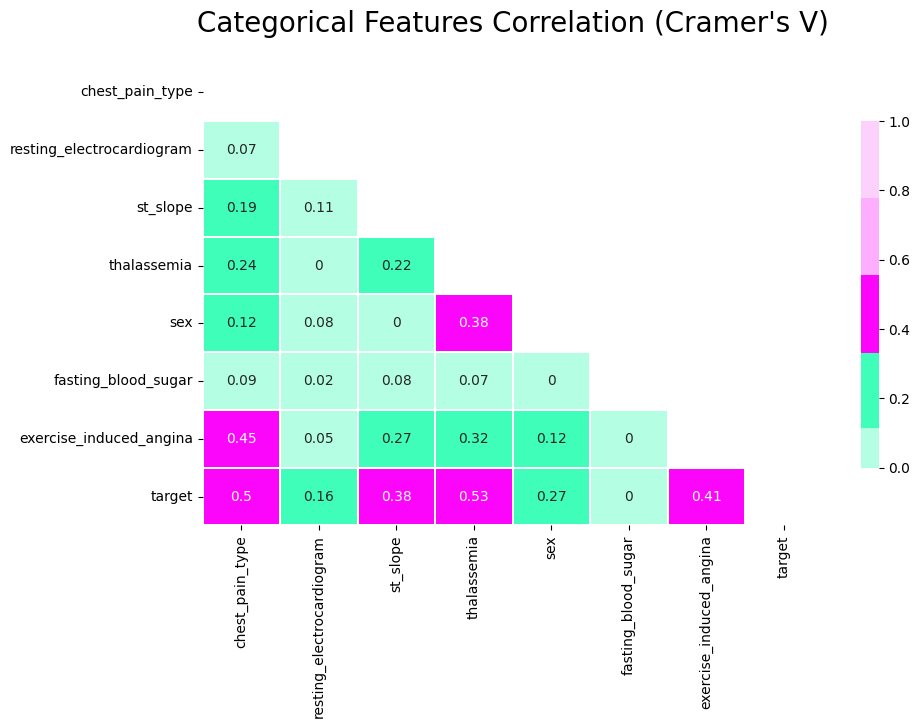

In [34]:
# =========================================================================================
# The `cramers_v` function below is copied from:
# https://towardsdatascience.com/the-search-for-categorical-correlation-a1cf7f1888c9
#
# GOAL:
#   Compute Cramér’s V, a measure of association (0..1) between TWO CATEGORICAL variables.
#   0 = no association, 1 = very strong association. It is based on the chi-square statistic.
# HOW (high level):
#   1) Build a contingency table of counts (x categories by y categories).
#   2) Run chi-square test → get χ².
#   3) Normalize χ² to phi² = χ² / n, apply bias correction.
#   4) Return sqrt( corrected_phi² / min(k-1, r-1) )  → a number in [0,1].
# =========================================================================================

def cramers_v(x, y):
    # pd.crosstab(x, y) → contingency table (2D table of counts):
    # rows = distinct labels in x; columns = distinct labels in y; each cell = count of (x_i,y_j).
    confusion_matrix = pd.crosstab(x,y)

    # stats.chi2_contingency(table) runs a chi-square test of independence on the contingency table.
    # It returns a tuple: (chi2, p, dof, expected). We only need the first element (chi2 statistic).
    chi2 = stats.chi2_contingency(confusion_matrix)[0]

    # Total sample size n = sum of ALL counts in the contingency table.
    # confusion_matrix.sum() sums down columns (gives row totals); .sum() again sums those → grand total.
    n = confusion_matrix.sum().sum()

    # phi^2 = chi2 / n : normalized chi-square (effect size basis).
    phi2 = chi2/n

    # confusion_matrix.shape → (r, k): number of rows (r) and columns (k) in the contingency table.
    r,k = confusion_matrix.shape

    # Bias correction to reduce upward bias in small/unbalanced tables:
    # 1) Subtract ((k-1)(r-1))/(n-1) from phi^2 (but not below 0).
    # 2) Adjust “effective” rows and columns counts (rcorr, kcorr).
    phi2corr = max(0, phi2-((k-1)*(r-1))/(n-1))
    rcorr = r-((r-1)**2)/(n-1)
    kcorr = k-((k-1)**2)/(n-1)

    # Final Cramér’s V = sqrt( phi2corr / min(kcorr-1, rcorr-1) ).
    # min(...) ensures proper scaling relative to the smaller dimension.
    # np.sqrt(...) computes the non-negative square root.
    return np.sqrt(phi2corr/min((kcorr-1),(rcorr-1)))

# =========================================================================================
# CALCULATE the pairwise Cramér’s V for all categorical features and plot as a heatmap.
# =========================================================================================

# data[cat_feats] → select ONLY the categorical columns listed in cat_feats from DataFrame `data`.
# This produces a new DataFrame `data_` containing just those categorical features.
data_ = data[cat_feats]

# We will build the full matrix of Cramér’s V values as a nested Python list:
# `rows` will hold each row; inside, `col` will hold each row’s values across all y-features.
rows= []

# for x in data_: iterates over the COLUMN NAMES of `data_` (same as for x in data_.columns).
# Each loop sets x to one categorical feature name.
for x in data_:
    # Start a fresh list for this row (x vs every y).
    col = []
    # Inner loop: y sweeps across ALL categorical feature names again to fill one row.
    for y in data_ :
        # Call our function on the two categorical Series (data_[x], data_[y]) to get Cramér’s V.
        cramers =cramers_v(data_[x], data_[y])
        # round(value, 2) → round to 2 decimal places to make the heatmap annotations clean.
        col.append(round(cramers,2))
    # Append the completed row to the big `rows` list.
    rows.append(col)

# Convert the nested list `rows` into a NumPy array (rectangular numeric matrix).
cramers_results = np.array(rows)

# Wrap the matrix in a pandas DataFrame for labeled axes (rows/cols),
# using the same column names as in `data_` for both index and columns (symmetric matrix).
df = pd.DataFrame(cramers_results, columns = data_.columns, index = data_.columns)

# =========================================================================================
# PLOTTING THE HEATMAP
# =========================================================================================

# Define a custom color palette for the heatmap. This is a simple list of hex color strings.
# You can repeat or vary colors to shape the gradient that gets built below.
mypal_1= ['#FC05FB', '#FEAEFE', '#FCD2FC','#F3FEFA', '#B4FFE4','#3FFEBA', '#FC05FB', '#FEAEFE', '#FCD2FC']

# Build a boolean mask to hide the UPPER HALF (including diagonal) of the symmetric matrix:
# np.ones_like(df, dtype=bool) → make a True-array with same shape as df.
# np.triu(...) keeps True on/above the main diagonal (upper triangle).
mask = np.triu(np.ones_like(df, dtype=bool))

# df.mask(mask) → replace values where mask==True with NaN (not-a-number).
# This effectively blanks the upper half so the heatmap won’t draw duplicate info.
corr = df.mask(mask)

# Create a new figure (f) and axes (ax) for the plot.
# figsize=(10, 6) → figure width 10 inches, height 6 inches. facecolor=None → default background.
f, ax = plt.subplots(figsize=(10, 6), facecolor=None)

# Turn the discrete list `mypal_1` into a continuous colormap usable by seaborn heatmap.
# sns.color_palette(..., as_cmap=True) blends the listed colors into a gradient map.
cmap = sns.color_palette(mypal_1, as_cmap=True)

# Draw the heatmap:
# - data=corr: the lower-half matrix of Cramér’s V values (upper half is NaN).
# - mask=mask: also tell seaborn to hide masked cells (upper half + diagonal).
# - cmap=cmap: use our custom gradient of colors.
# - vmax=1.0, vmin=0: Cramér’s V ranges from 0 to 1, so fix the color scale to that range.
# - center=0: defines the neutral midpoint color at 0 (fine since range is [0,1]).
# - annot=True: print the numeric value in each visible cell.
# - square=False: cells can be rectangular (True would force squares).
# - linewidths=.01: thin lines between cells (grid look).
# - cbar_kws={"shrink": 0.75}: shrink the color bar to 75% of its default size for a better fit.
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=1.0, vmin=0, center=0, annot=True,
            square=False, linewidths=.01, cbar_kws={"shrink": 0.75})

# Set a descriptive title on the axes (the plotting area).
# fontsize=20 makes it larger; y=1.05 nudges it a bit above the axes so it doesn’t overlap.
ax.set_title("Categorical Features Correlation (Cramer's V)", fontsize=20, y= 1.05);

In [35]:
# # the cramers_v function is copied from https://towardsdatascience.com/the-search-for-categorical-correlation-a1cf7f1888c9

# def cramers_v(x, y):
#     confusion_matrix = pd.crosstab(x,y)
#     chi2 = stats.chi2_contingency(confusion_matrix)[0]
#     n = confusion_matrix.sum().sum()
#     phi2 = chi2/n
#     r,k = confusion_matrix.shape
#     phi2corr = max(0, phi2-((k-1)*(r-1))/(n-1))
#     rcorr = r-((r-1)**2)/(n-1)
#     kcorr = k-((k-1)**2)/(n-1)
#     return np.sqrt(phi2corr/min((kcorr-1),(rcorr-1)))

# # calculate the correlation coefficients using the above function
# data_ = data[cat_feats]
# rows= []
# for x in data_:
#     col = []
#     for y in data_ :
#         cramers =cramers_v(data_[x], data_[y])
#         col.append(round(cramers,2))
#     rows.append(col)

# cramers_results = np.array(rows)
# df = pd.DataFrame(cramers_results, columns = data_.columns, index = data_.columns)

# # color palette
# mypal_1= ['#FC05FB', '#FEAEFE', '#FCD2FC','#F3FEFA', '#B4FFE4','#3FFEBA', '#FC05FB', '#FEAEFE', '#FCD2FC']
# # plot the heat map
# mask = np.triu(np.ones_like(df, dtype=bool))
# corr = df.mask(mask)
# f, ax = plt.subplots(figsize=(10, 6), facecolor=None)
# cmap = sns.color_palette(mypal_1, as_cmap=True)
# sns.heatmap(corr, mask=mask, cmap=cmap, vmax=1.0, vmin=0, center=0, annot=True,
#             square=False, linewidths=.01, cbar_kws={"shrink": 0.75})
# ax.set_title("Categorical Features Correlation (Cramer's V)", fontsize=20, y= 1.05);

<a href="#top">☝️ Back to top</a>

## **1.5 EDA Summary**: <a class="anchor" id="1.5"></a>

* Data size: 303 rows and 14 columns (13 independent + one target variable) > later reduced to 296 after removing faulty data points!
* Data has no missing values
* Features (columns) data type:
    * Six features are numerical
    * The rest (seven features) are categorical variables
* Target variable is fairly balanced, 54% no-disease to 46% has-disease
* Correlations:
    * Correlation between features is weak at best
    * From the numerical features `num_major_vessels`, `max_heart_rate_achieved`, and `st_depression` are reasonably correlated with the target variable at -0.47, 0.43, and -0.43 correlation coefficients, respectively.
    * From the categorical features `chest_pain_type`, `num_major_vessels`, `thalassemia`, and `exercise_induced_angina` are better correlated with the target variable, `thalassemia` being the highest at 0.52.
    * Cholesterol (to my surprise, but what do I know?) has less correlation with heart disease.
    
**Takeaway**: features that have higher predictive power could be, **`chest_pain_type`, `num_major_vessels`, `thalassemia`, `exercise_induced_angina` `max_heart_rate_achieved`** and **`st_depression`**. We will see which features will appear as important by the classification models.
            

---
# 2. **Models Development (Predictions)** <a class="anchor" id="2"></a>
---
**Note** : We have only 297 case (after data cleaning) which is a very small amount of data to do any serious prediction. Therefore, any conclusion made must be taken with cautions. This notebook is merely an excercise on binary classification algorithms.

## 2.1 **Scikit Learn Classifiers** <a class="anchor" id="2.1"></a>

This is a binary classification problem (has-disease or no-disease cases). Scikit learn offers a wide range of classification algorithms and is often the starting point in most/traditional machine learning challenges, so we start by exploring few of the classification alorithms from the sklearn libarary such as `Logistic Regression`, `Nearest Neighbors`, `Linear SVC`, `Nu SVC`, `Decision Tree`, `Random Forest`, `AdaBoost`, `Gradient Boosting`, `Naive Bayes`, `Linear Discriminant Analysis`, `Quadratic Discriminant Analysis` and `Neural Net`. Let's first build simple models using the above mentioned ML algorithms and later we will optimize them by tuning the parameters.

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, LinearSVC, NuSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.metrics import recall_score, accuracy_score,roc_curve, auc
from sklearn.model_selection import train_test_split
# from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.preprocessing import LabelEncoder
import shap

ModuleNotFoundError: No module named 'shap'

In [37]:
cat_feats

['chest_pain_type',
 'resting_electrocardiogram',
 'st_slope',
 'thalassemia',
 'sex',
 'fasting_blood_sugar',
 'exercise_induced_angina',
 'target']

In [38]:
def label_encode_cat_features(data, cat_features):
    '''
    Given a dataframe and its categorical features, this function returns label-encoded dataframe
    '''

    # Create one LabelEncoder object that can encode labels (strings) as integers.
    # LabelEncoder maps each unique text value in a column to a number: 0, 1, 2, ...
    label_encoder = LabelEncoder()

    # .copy() creates a separate DataFrame so we do not modify the original 'data' in place.
    data_encoded = data.copy()

    # Loop over each column name in the list 'cat_features'.
    # 'for col in cat_features' means: do the next indented block once per column.
    for col in cat_features:

        # For the current categorical column:
        # 1) .fit() learns the mapping from text to numbers, based on the unique values in that column
        # 2) .transform() applies that mapping to convert the column into numbers
        # .fit_transform() does both steps in one go
        # We assign the encoded numeric column back into the copied DataFrame.
        data_encoded[col] = label_encoder.fit_transform(data[col])

    # Reassign the local variable 'data' to the encoded version.
    # This does not change the original variable outside the function. It just sets what we will return.
    data = data_encoded

    # Return the encoded DataFrame to the caller.
    return data


# -----------------------------------------
# STEP 1: Split the data into train and test sets
# -----------------------------------------

# 'cat_features' is a list of all the categorical (non-numeric) columns in your dataset.
#  You already created or imported 'cat_feats' earlier.
cat_features = cat_feats

# Before we train any machine learning model, categorical data (like text labels)
# must be converted to numeric form. We use the label_encode_cat_features() function
# (defined earlier) to replace text categories with numbers.
data = label_encode_cat_features(data, cat_features)

# 'seed' sets a fixed random number generator value.
# This ensures that when we re-run the code, the train/test split and model behavior
# remain the same every time. (i.e., reproducible results)
seed = 0

# 'test_size' controls how much of the data goes into the validation/test set.
# 0.25 means 25% of your total data will be used for validation/testing,
# and the remaining 75% will be used for training.
test_size = 0.25

# The dataset is assumed to have multiple columns, and the last column is the target (label).
# Here, we take all columns except the last one as features (inputs).
features = data.columns[:-1]

# Create the input and output sets:
# X contains the features used for prediction.
# y contains the target (the value we want to predict, usually labeled 'target' in the dataset).
X = data[features]
y = data['target']

# Split the dataset into training and validation (testing) sets.
# train_test_split is a function from sklearn.model_selection.
# X_train, y_train → used to train the model.
# X_val, y_val → used later to check how well the model performs on unseen data.
# test_size = 0.25 means 25% of data is used for validation.
# random_state = seed ensures the split is the same every time.
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=test_size, random_state=seed)


# -----------------------------------------
# STEP 2: Define the classifiers (algorithms)
# -----------------------------------------

# Here we create a list of names that match each classifier.
# This helps us keep track of which model produced which results later on.
names = [
    'Logistic Regression',        # a linear model used for binary classification
    'Nearest Neighbors',          # KNN algorithm that classifies based on closest data points
    'Support Vectors',          # Support Vector Classifier (SVC), finds best separation boundary
    'Nu SVC',                     # Variant of SVC that uses different parameters (nu)
    'Decision Tree',              # Builds a tree-like model based on feature splits
    'Random Forest',              # Ensemble of many decision trees for better accuracy
    'AdaBoost',                   # Boosting technique that combines weak models to form a strong one
    'Gradient Boosting',          # Another boosting method that focuses on improving errors sequentially
    'Naive Bayes',                # Probabilistic classifier based on Bayes’ theorem
    'Linear DA',                  # Linear Discriminant Analysis (LDA) — works well for normally distributed features
    'Quadratic DA',             # Quadratic Discriminant Analysis (QDA) — allows curved decision boundaries
    "Neural Net"                  # Multi-layer Perceptron (basic feedforward neural network)
]

# For each name above, we now define the actual model objects.
# These come from sklearn’s classifier classes.
# We use default hyperparameters for simplicity, but you can tune them later.

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, NuSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis,
    QuadraticDiscriminantAnalysis
)
from sklearn.neural_network import MLPClassifier

# Each classifier object is created with its typical setup:
classifiers = [
    LogisticRegression(solver="liblinear", random_state=seed),
    # 'solver="liblinear"' is suitable for small datasets or binary classification.
    # random_state makes it reproducible.

    KNeighborsClassifier(2),
    # Uses 2 nearest neighbors to classify a data point.
    # You can adjust the number inside parentheses for different performance.

    SVC(probability=True, random_state=seed),
    # SVC = Support Vector Classifier.
    # 'probability=True' lets us later use .predict_proba() for ROC curve plotting.
    # This can slow training but enables probability estimates.

    NuSVC(probability=True, random_state=seed),
    # Similar to SVC but uses a 'nu' parameter instead of 'C' to control margin flexibility.

    DecisionTreeClassifier(random_state=seed),
    # Builds a single decision tree model.
    # random_state ensures the same splits are used each time.

    RandomForestClassifier(random_state=seed),
    # Builds multiple trees and averages their results (reduces overfitting).

    AdaBoostClassifier(random_state=seed),
    # Trains a sequence of weak learners (usually small decision trees),
    # each focusing on fixing the previous one’s mistakes.

    GradientBoostingClassifier(random_state=seed),
    # Similar to AdaBoost but uses gradient descent to improve prediction errors.

    GaussianNB(),
    # Implements Naive Bayes assuming feature values follow a Gaussian (normal) distribution.

    LinearDiscriminantAnalysis(),
    # Separates classes using a linear combination of features.

    QuadraticDiscriminantAnalysis(),
    # Like LDA but allows non-linear class boundaries.

    MLPClassifier(random_state=seed),
    # MLP = Multi-Layer Perceptron — a basic neural network.
    # random_state ensures consistent weight initialization.
]


def score_summary(names, classifiers):
    '''
    Given a list of classiers, this function calculates the accuracy,
    ROC_AUC and Recall and returns the values in a dataframe
    '''

    # This defines the column headers we want in the summary table.
    cols = ["Classifier", "Accuracy", "ROC_AUC", "Recall", "Precision", "F1"]

    # Create an empty DataFrame with the desired columns to store results for each classifier.
    data_table = pd.DataFrame(columns=cols)

    # zip(names, classifiers) pairs each name with the matching classifier object.
    # Example: names = ["LogReg", "RF"], classifiers = [LogisticRegression(), RandomForestClassifier()]
    # The loop runs once per pair.
    for name, clf in zip(names, classifiers):

        # Train the model on the training data.
        # .fit(features, labels) learns parameters from X_train and y_train.
        clf.fit(X_train, y_train)

        # Make class predictions on the validation set.
        # pred will be a vector like [0, 1, 0, 0, 1, ...]
        pred = clf.predict(X_val)

        # Compute Accuracy = proportion of correct predictions.
        accuracy = accuracy_score(y_val, pred)

        # Some classifiers support predicted probabilities via .predict_proba()
        # This returns two columns for a binary problem:
        #   column 0 = probability of class 0
        #   column 1 = probability of class 1
        # We take [:, 1] to get the probability of the positive class.
        # NOTE: For SVC you must init with probability=True to use predict_proba.
        pred_proba = clf.predict_proba(X_val)[:, 1]

        # Compute ROC curve points:
        # fpr = false positive rate at various thresholds
        # tpr = true positive rate at those thresholds
        # thresholds = the probability cutoffs used to trace the curve
        fpr, tpr, thresholds = roc_curve(y_val, pred_proba)

        # Compute the area under the ROC curve from the fpr and tpr arrays.
        roc_auc = auc(fpr, tpr)

        # Build the confusion matrix using the predicted labels vs true labels.
        # Layout:
        # [[TN, FP],
        #  [FN, TP]]
        cm = confusion_matrix(y_val, pred)

        # Extract values by index:
        # cm[1,1] is TP, cm[1,0] is FN, cm[0,1] is FP, cm[0,0] is TN
        TP = cm[1, 1]
        FN = cm[1, 0]
        FP = cm[0, 1]
        # TN = cm[0, 0]  # Not used below, but shown for completeness

        # Recall = TP / (TP + FN)
        # Of the actual positive cases, how many did we correctly identify
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0

        # Precision = TP / (TP + FP)
        # Of the predicted positive cases, how many were correct
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0

        # F1 score is the harmonic mean of Precision and Recall
        # F1 = 2 * (Precision * Recall) / (Precision + Recall)
        f1 = 2 * recall * precision / (recall + precision) if (recall + precision) > 0 else 0.0

        # Create a one-row DataFrame with the metrics for this classifier.
        # accuracy*100 converts accuracy to a percentage for easier reading.
        df = pd.DataFrame(
            [[name, accuracy * 100, roc_auc, recall, precision, f1]],
            columns=cols
        )

        # Append the row to the results table.
        # NOTE: DataFrame.append is deprecated in recent pandas.
        # You can replace with:
        #   data_table = pd.concat([data_table, df], ignore_index=True)
        data_table = data_table.append(df)

    # .reset_index(drop=True) gives the rows a clean 0..N-1 index.
    # np.round(..., 2) rounds all numbers to 2 decimal places for neat display.
    return np.round(data_table.reset_index(drop=True), 2)


def plot_conf_matrix(names, classifiers, nrows, ncols, fig_a, fig_b):
    '''
    Plots confusion matrices in a subplots.

    Args:
        names : list of names of the classifier
        classifiers : list of classification algorithms
        nrows, ncols : number of rows and rows in the subplots
        fig_a, fig_b : dimensions of the figure size
    '''

    # Create a figure with a grid of subplots.
    # figsize takes width and height in inches, so (fig_a, fig_b) controls overall size.
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(fig_a, fig_b))

    # We will loop through each classifier and each axis panel together.
    # axes.flatten() turns the grid into a simple 1D list so we can zip over it.
    i = 0
    for clf, ax in zip(classifiers, axes.flatten()):

        # Train the classifier on the training set.
        clf.fit(X_train, y_train)

        # Draw the confusion matrix for this classifier on the given axis.
        # Modern sklearn prefers ConfusionMatrixDisplay.from_estimator:
        ConfusionMatrixDisplay.from_estimator(clf, X_val, y_val, ax=ax)
        # If you must use the older helper, uncomment and ensure it exists in your sklearn:
        # plot_confusion_matrix(clf, X_val, y_val, ax=ax)

        # Set the subplot title to the matching classifier name.
        ax.title.set_text(names[i])
        i = i + 1

    # Adjust spacing so subplot titles and axes do not overlap.
    plt.tight_layout()

    # Show the figure on the screen.
    plt.show()


def roc_auc_curve(names, classifiers):
    '''
    Given a list of classifiers, this function plots the ROC curves
    '''

    # Create a new figure with a fixed size in inches.
    plt.figure(figsize=(12, 8))

    # Loop over each (name, classifier) pair.
    for name, clf in zip(names, classifiers):

        # Train on the training data.
        clf.fit(X_train, y_train)

        # Predict the positive class probabilities on the validation features.
        # [:, 1] selects the second column which corresponds to class 1.
        pred_proba = clf.predict_proba(X_val)[:, 1]

        # Compute the ROC curve points and AUC for this classifier.
        fpr, tpr, thresholds = roc_curve(y_val, pred_proba)
        roc_auc = auc(fpr, tpr)

        # Plot the ROC curve line:
        #   x-axis is FPR
        #   y-axis is TPR
        # lw is line width
        # label shows the classifier name and the AUC value in the legend.
        plt.plot(fpr, tpr, lw=3, label=name + ' ROC curve (area = %0.2f)' % (roc_auc))

    # Plot a diagonal reference line that represents random guessing.
    # This helps you visually compare your curves against a no-skill classifier.
    plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')

    # Set the visible range of the axes from 0 to 1 for both x and y,
    # which is standard for ROC plots.
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.0])

    # Label the axes to explain what the chart shows.
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')

    # Set a clear title for the figure. fontsize controls text size.
    plt.title('Receiver operating characteristic (ROC) curves', fontsize=20)

    # Show the legend in the lower right corner so it does not cover most of the curves.
    plt.legend(loc="lower right")

    # Finally draw the plot.
    plt.show()

In [ ]:
# # -----------------------------------------
# # STEP 1: Split the data into train and test sets
# # -----------------------------------------

# # 'cat_features' is a list of all the categorical (non-numeric) columns in your dataset.
# # Here we assume you already created or imported 'cat_feats' earlier.
# cat_features = cat_feats

# # Before we train any machine learning model, categorical data (like text labels)
# # must be converted to numeric form. We use the label_encode_cat_features() function
# # (defined earlier) to replace text categories with numbers.
# data = label_encode_cat_features(data, cat_features)

# # 'seed' sets a fixed random number generator value.
# # This ensures that when you re-run the code, the train/test split and model behavior
# # remain the same every time. (i.e., reproducible results)
# seed = 0

# # 'test_size' controls how much of the data goes into the validation/test set.
# # 0.25 means 25% of your total data will be used for validation/testing,
# # and the remaining 75% will be used for training.
# test_size = 0.25

# # The dataset is assumed to have multiple columns, and the last column is the target (label).
# # Here, we take all columns except the last one as features (inputs).
# features = data.columns[:-1]

# # Create the input and output sets:
# # X contains the features used for prediction.
# # y contains the target (the value we want to predict, usually labeled 'target' in the dataset).
# X = data[features]
# y = data['target']

# # Split the dataset into training and validation (testing) sets.
# # train_test_split is a function from sklearn.model_selection.
# # X_train, y_train → used to train the model.
# # X_val, y_val → used later to check how well the model performs on unseen data.
# # test_size = 0.25 means 25% of data is used for validation.
# # random_state = seed ensures the split is the same every time.
# from sklearn.model_selection import train_test_split
# X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=test_size, random_state=seed)


# # -----------------------------------------
# # STEP 2: Define the classifiers (algorithms)
# # -----------------------------------------

# # Here we create a list of names that match each classifier.
# # This helps us keep track of which model produced which results later on.
# names = [
#     'Logistic Regression',        # a linear model used for binary classification
#     'Nearest Neighbors',          # KNN algorithm that classifies based on closest data points
#     'Support Vectors',            # Support Vector Classifier (SVC), finds best separation boundary
#     'Nu SVC',                     # Variant of SVC that uses different parameters (nu)
#     'Decision Tree',              # Builds a tree-like model based on feature splits
#     'Random Forest',              # Ensemble of many decision trees for better accuracy
#     'AdaBoost',                   # Boosting technique that combines weak models to form a strong one
#     'Gradient Boosting',          # Another boosting method that focuses on improving errors sequentially
#     'Naive Bayes',                # Probabilistic classifier based on Bayes’ theorem
#     'Linear DA',                  # Linear Discriminant Analysis (LDA) — works well for normally distributed features
#     'Quadratic DA',               # Quadratic Discriminant Analysis (QDA) — allows curved decision boundaries
#     "Neural Net"                  # Multi-layer Perceptron (basic feedforward neural network)
# ]

# # For each name above, we now define the actual model objects.
# # These come from sklearn’s classifier classes.
# # We use default hyperparameters for simplicity, but you can tune them later.

# from sklearn.linear_model import LogisticRegression
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.svm import SVC, NuSVC
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.ensemble import (
#     RandomForestClassifier,
#     AdaBoostClassifier,
#     GradientBoostingClassifier
# )
# from sklearn.naive_bayes import GaussianNB
# from sklearn.discriminant_analysis import (
#     LinearDiscriminantAnalysis,
#     QuadraticDiscriminantAnalysis
# )
# from sklearn.neural_network import MLPClassifier

# # Each classifier object is created with its typical setup:
# classifiers = [
#     LogisticRegression(solver="liblinear", random_state=seed),
#     # 'solver="liblinear"' is suitable for small datasets or binary classification.
#     # random_state makes it reproducible.

#     KNeighborsClassifier(2),
#     # Uses 2 nearest neighbors to classify a data point.
#     # You can adjust the number inside parentheses for different performance.

#     SVC(probability=True, random_state=seed),
#     # SVC = Support Vector Classifier.
#     # 'probability=True' lets us later use .predict_proba() for ROC curve plotting.
#     # This can slow training but enables probability estimates.

#     NuSVC(probability=True, random_state=seed),
#     # Similar to SVC but uses a 'nu' parameter instead of 'C' to control margin flexibility.

#     DecisionTreeClassifier(random_state=seed),
#     # Builds a single decision tree model.
#     # random_state ensures the same splits are used each time.

#     RandomForestClassifier(random_state=seed),
#     # Builds multiple trees and averages their results (reduces overfitting).

#     AdaBoostClassifier(random_state=seed),
#     # Trains a sequence of weak learners (usually small decision trees),
#     # each focusing on fixing the previous one’s mistakes.

#     GradientBoostingClassifier(random_state=seed),
#     # Similar to AdaBoost but uses gradient descent to improve prediction errors.

#     GaussianNB(),
#     # Implements Naive Bayes assuming feature values follow a Gaussian (normal) distribution.

#     LinearDiscriminantAnalysis(),
#     # Separates classes using a linear combination of features.

#     QuadraticDiscriminantAnalysis(),
#     # Like LDA but allows non-linear class boundaries.

#     MLPClassifier(random_state=seed),
#     # MLP = Multi-Layer Perceptron — a basic neural network.
#     # random_state ensures consistent weight initialization.
# ]


In [ ]:
# # split the data into train and test sets

# cat_features = cat_feats
# data = label_encode_cat_features(data, cat_features)

# seed = 0
# test_size = 0.25

# features = data.columns[:-1]

# X = data[features]
# y = data['target']

# X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = test_size, random_state=seed)


# # classifier algorithms with default parameters

# names = [
#     'Logistic Regression',
#     'Nearest Neighbors',
#     'Support Vectors',
#     'Nu SVC',
#     'Decision Tree',
#     'Random Forest',
#     'AdaBoost',
#     'Gradient Boosting',
#     'Naive Bayes',
#     'Linear DA',
#     'Quadratic DA',
#     "Neural Net"
# ]

# classifiers = [
#     LogisticRegression(solver="liblinear", random_state=seed),
#     KNeighborsClassifier(2),
#     SVC(probability=True, random_state=seed),
#     NuSVC(probability=True, random_state=seed),
#     DecisionTreeClassifier(random_state=seed),
#     RandomForestClassifier(random_state=seed),
#     AdaBoostClassifier(random_state=seed),
#     GradientBoostingClassifier(random_state=seed),
#     GaussianNB(),
#     LinearDiscriminantAnalysis(),
#     QuadraticDiscriminantAnalysis(),
#     MLPClassifier(random_state=seed),
# ]


### 2.1.1 Performance metric

There are several metrics that can be used to gauge the performance of a given classification algorithm. The choice of the '*appropriate*' metrics is then dependent on the type of problem we are dealing with. There are case where, for example, *accuracy* can be the right choice and in some other case a *recall* or *precision* could be more fitting to the purpose. Since we are dealing with medical case (classify if a case is positive for heart disease or not), we could use recall (true positive rate or sensitivity) as performance metrics to choose our classifier. Note here that we do not want to classify positive (has disease) cases as negative (no disease).

**Confusion matrix** : A confusion matrix (aka an error matrix) is a specific table layout that allows visualization of the performance of a supervised learning algorithm. Each row of the matrix represents the instances in an *actual* class while each column represents the instances in a *predicted* class [[wiki](https://en.wikipedia.org/wiki/Confusion_matrix)]. The table below is an example of a confusion matrix for a binary classification from which other terminologies/metric can be derived. Some of the metrics are described below.

<div>    
<img src="https://miro.medium.com/max/875/1*LQ1YMKBlbDhH9K6Ujz8QTw.jpeg" width="350", align="center"/>  
</div>

[Image credit >>](https://towardsdatascience.com/demystifying-confusion-matrix-29f3037b0cfa)

---

**Key**:

|**Term** |**Meaning** | **Descriptions**|
| --- |---|---|
|TP |True Positive|Positive cases which are predicted as positive|
|FP |False Positive|Negative cases which are predicted as positive|
|TN |True Negative|Negative cases which are predicted as negative|
|FN |False Negative|Positive cases which are predicted as negative|

---
**Accuracy** : Measures how many of the cases are correctly identified/predicted by the model, i.e correct prediction divided by the total sample size.

$\frac{TP + TN}{TP +TN + FP + FN}$

**Recall**: Measures the rate of *true positives*, i.e how many of the *actual* positive cases are *identified/predicted* as positive by the model.

$\frac{TP}{(TP + FN)}$

**Precision**: Measures how many of the positive predicted cases are actually positive.

$\frac{TP}{(TP + FP)}$

**F1-Score** : Combines the precision and recall of the model and it is defined as the harmonic mean of the model’s precision and recall.

$2\frac{recall * precision}{recall + precision}$

**ROC curves** : A receiver operating characteristic (ROC) curve, is a graphical plot which illustrates the performance of a binary classification algorithm as a function of true positive rate and false positive rate.

<a href="#top">☝️ Back to top</a>

### 2.1.2 Performance metrics summary table

In [ ]:
# We call our results function to compute the metrics table for all models,
# then we sort and style it for an easy-to-read visual summary.

# 1) score_summary(names, classifiers)
#    - Runs each classifier on X_train/y_train and evaluates on X_val/y_val
#    - Returns a pandas DataFrame with columns:
#      ["Classifier", "Accuracy", "ROC_AUC", "Recall", "Precision", "F1"]
#    - In your implementation, "Accuracy" is a percentage (accuracy*100), while the
#      others are between 0 and 1. Keep that in mind when reading the bars.
#
# 2) .sort_values(by='Accuracy', ascending=False)
#    - Sorts rows so the highest Accuracy appears first (top of the table).
#
# 3) .style
#    - Switches from a plain DataFrame to a Styler object.
#    - A Styler lets you add colors, gradients, and bar charts that show up nicely
#      in notebooks (Jupyter, VS Code notebooks) or when exported to HTML.
#
# 4) .background_gradient(cmap='coolwarm')
#    - Applies a background color gradient to ALL numeric columns by default.
#    - "cmap" chooses the color map. 'coolwarm' has blue for lower values and red for higher values.
#    - Use this to quickly see which models scored low or high per column.
#
# 5) .bar(subset=["ROC_AUC"], color='#6495ED')
#    - Draws horizontal bar visuals inside the "ROC_AUC" column cells.
#    - "subset" tells Styler which column to apply the effect to.
#    - The color is set with a hex code (here, a cornflower blue).
#    - Bars are scaled by the column’s min and max.
#
# 6) .bar(subset=["Recall"], color='#ff355d')
#    - Adds bars for the "Recall" column (bright pink/red).
#
# 7) .bar(subset=["Precision"], color='lightseagreen')
#    - Adds bars for the "Precision" column.
#
# 8) .bar(subset=["F1"], color='gold')
#    - Adds bars for the "F1" column.
#
# Notes:
# - The result is a Styler. In Jupyter, the last line of a cell auto-displays it.
#   If it does not display, wrap the whole expression with: from IPython.display import display; display(...)
# - If you want to export to HTML, use .to_html("file.html") on the Styler.
# - If any of the styled columns contain non-numeric values (strings, NaN without proper handling),
#   Styler bar/gradient may fail. Ensure the metric columns are numeric.
# - Accuracy is a percentage in your summary (0–100). AUC/Recall/Precision/F1 are 0–1.
#   That is fine, Styler will scale each column independently.
# - Backslashes for line continuation work, but parentheses are safer and more robust.
#   See the alternative version below.

score_summary(names, classifiers).sort_values(by='Accuracy' , ascending=False) \
    .style \
    .background_gradient(cmap='coolwarm') \
    .bar(subset=["ROC_AUC"], color='#6495ED') \
    .bar(subset=["Recall"], color='#ff355d') \
    .bar(subset=["Precision"], color='lightseagreen') \
    .bar(subset=["F1"], color='gold')


NameError: name 'names' is not defined

### 2.1.3 ROC curves

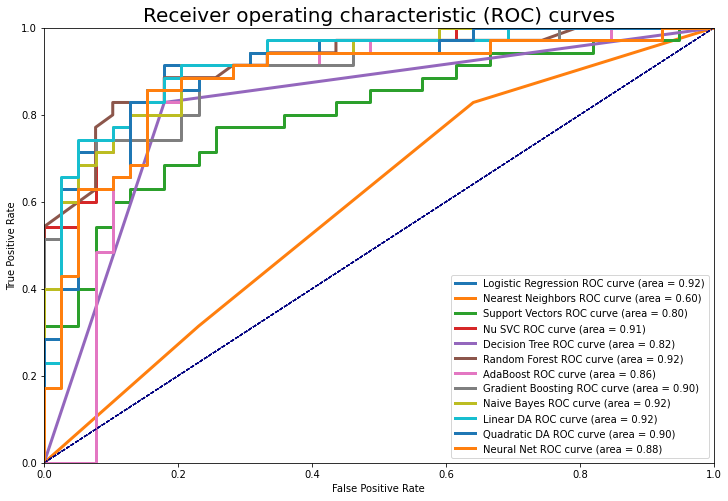

In [ ]:
roc_auc_curve(names, classifiers)

### 2.1.4 Confusion matrix

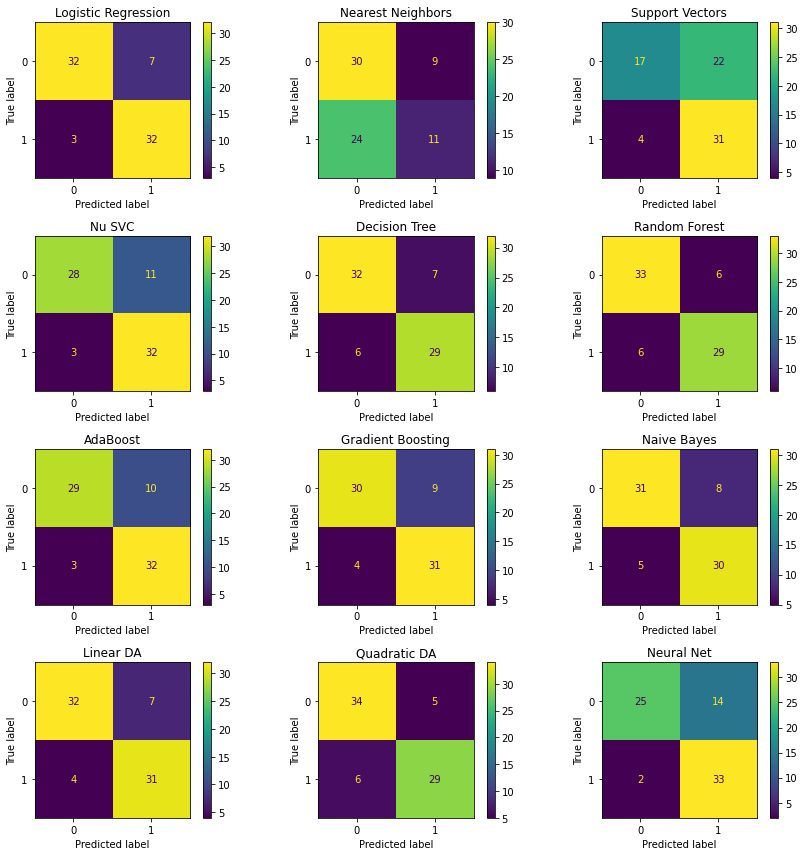

In [ ]:
plot_conf_matrix(names, classifiers, nrows=4, ncols=3, fig_a=12, fig_b=12)

Now we have seen all the performance metrics of the classifiers, it is decision time for us to choose the best possible classifier algorithm. Based on precision LR ranks first (86%); whereas if we see the recall, Neural Nets ranks first with 94%. In the case of precision, QDA ranks first with 85%. So which one to choose? The F1-score can give us a balance between recall and precision. LR happens to have the best F1-score so we choose Logistic Regression as our best classifier.

**Note**: If I were consulting a clinic doing a heart disease screening test, I would like to strike a perfect balance between precision and recall (I don't want the clinic to risk their reputation of by handing out too many false positive result but all without risking their clients' health by predicting too many false negatives). Therefore, I would advice them to choose the model which gives a higher F1-score, i.e the Logistic regression model.

### 2.1.5 Parameter Tuning (RandomizedSearch): LogisticRegression

So chosen our best classifier, the Logistic regression model. However, this was achieved with default parameters. The intuition is that we could further improve our model with tuned parameters. Let's see if could achieve that using the scikit-learn RandomizedSearch algorithm.  

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform
from sklearn.model_selection import RepeatedStratifiedKFold


lr = LogisticRegression(tol=1e-4, max_iter=1000, random_state=seed)

space = dict(C=uniform(loc=0, scale=5),
                     penalty=['l2', 'l1'],
                     solver= ['liblinear'])

search = RandomizedSearchCV(lr,
                         space,
                         random_state=seed,
                         cv = 5,
                         scoring='f1')

rand_search = search.fit(X_train, y_train)

print('Best Hyperparameters: %s' % rand_search.best_params_)

Best Hyperparameters: {'C': 0.2835648865872159, 'penalty': 'l2', 'solver': 'liblinear'}


In [ ]:
params = rand_search.best_params_
lr = LogisticRegression(**params)
lr.fit(X_train, y_train)
print(classification_report(y_val, lr.predict(X_val)))

              precision    recall  f1-score   support

           0       0.91      0.82      0.86        39
           1       0.82      0.91      0.86        35

    accuracy                           0.86        74
   macro avg       0.87      0.87      0.86        74
weighted avg       0.87      0.86      0.86        74



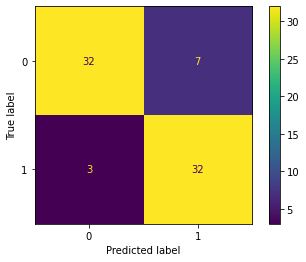

In [ ]:
plot_confusion_matrix(lr, X_val, y_val)

**Remark** : It turns out that our base model (default params) is not bad at all. Parameter tuning did not help to further increase the performance.

<a href="#top">☝️ Back to top</a>

## 2.2 **Catboost, Lgbm and Xgboost** <a class="anchor" id="2.2"></a>

In the above section (&&2.1) we have seen classifiers out of the scikit-learn library. Now we will try the modern (boosted trees) ML algorithms such as the [**catboost**](https://catboost.ai/), [**xgboost**](https://xgboost.readthedocs.io/en/stable/#) and [**lgbm**](https://lightgbm.readthedocs.io/en/latest/index.html). They are optimized machine learning algorithms based on the [**gradient-boosting**](https://en.wikipedia.org/wiki/Gradient_boosting) technique. Depending on the problem at hand, one algorithm is may be better suited than others. For detailed info one can easily refer to their documentations.

In [ ]:
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

names_boost =[
    'Catboost',
    'xgbbost',
    'light GBM'
]
classifiers = [
    CatBoostClassifier(random_state=seed, verbose=0),
    XGBClassifier(objective= 'binary:logistic', random_state=seed),
    LGBMClassifier(random_state=seed)
   ]

### 2.2.1 Performance metrics summary table

In [ ]:
score_summary(names_boost, classifiers).sort_values(by='Accuracy' , ascending = False)\
.style.background_gradient(cmap='coolwarm')\
.bar(subset=["ROC_AUC",], color='#6495ED')\
.bar(subset=["Recall"], color='#ff355d')\
.bar(subset=["Precision"], color='lightseagreen')\
.bar(subset=["F1"], color='gold')

[17:04:28] WARNING: ../src/learner.cc:1095: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


,Classifier,Accuracy,ROC_AUC,Recall,Precision,F1
0,Catboost,82.430000,0.920000,0.830000,0.810000,0.820000
2,light GBM,82.430000,0.910000,0.860000,0.790000,0.820000
1,xgbbost,79.730000,0.920000,0.830000,0.760000,0.790000


### 2.2.2 Confusion matrix

[17:04:30] WARNING: ../src/learner.cc:1095: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


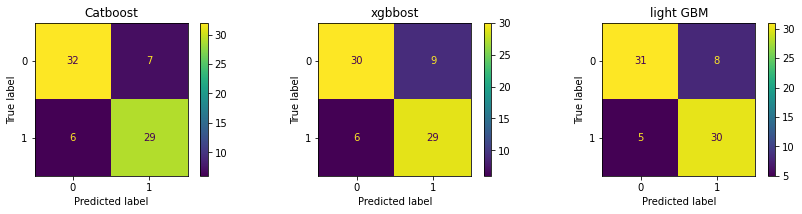

In [ ]:
plot_conf_matrix(names=names_boost, classifiers=classifiers, nrows=1, ncols=3, fig_a=12, fig_b=3);

**Remark** : Here we can see that the lgbm calssifier is marginally better than the other two and we will go for it. Following the same procedure, we will try to tune the parameters in the next section.

### 2.2.3 Parameter Tuning (RandomizedSearch): LGBMClassifier

In [ ]:
from sklearn.model_selection import GridSearchCV
rs_params = {
    'num_leaves': [20, 100],
    'max_depth': [5, 15],
    'min_data_in_leaf': [80, 120],
}
rs_cv = GridSearchCV(estimator=LGBMClassifier(random_state=seed, verbose=-1),
                           param_grid=rs_params,
                           cv = 5)

rs_cv.fit(X_train, y_train)
params = rs_cv.best_params_
params

[LightGBM] [Warning] min_data_in_leaf is set=80, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=80
[LightGBM] [Warning] min_data_in_leaf is set=80, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=80
[LightGBM] [Warning] min_data_in_leaf is set=80, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=80
[LightGBM] [Warning] min_data_in_leaf is set=80, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=80
[LightGBM] [Warning] min_data_in_leaf is set=80, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=80
[LightGBM] [Warning] min_data_in_leaf is set=80, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=80
[LightGBM] [Warning] min_data_in_leaf is set=80, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=80
[LightGBM] [Warning] min_data_in_leaf is set=80, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=80
[LightGBM] [Warning] min

{'max_depth': 5, 'min_data_in_leaf': 80, 'num_leaves': 20}

In [ ]:
lgbm = LGBMClassifier(**params);

lgbm.fit(X_train, y_train,
        eval_set=(X_val, y_val),
        verbose=False,
);

print(classification_report(y_val, lgbm.predict(X_val)))

              precision    recall  f1-score   support

           0       0.94      0.79      0.86        39
           1       0.80      0.94      0.87        35

    accuracy                           0.86        74
   macro avg       0.87      0.87      0.86        74
weighted avg       0.88      0.86      0.86        74



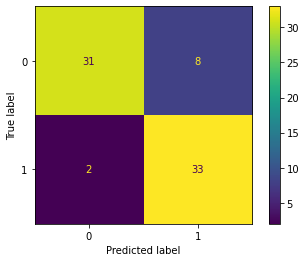

In [ ]:
plot_confusion_matrix(lgbm, X_val, y_val);

**Remark**: In this case (Lgbm) hyper-parameter tuning gave better results than the base model. We have increased the recall value from 86% to 94%. Which means we have decrease the rate of false negatives from 5 cases to 2 in our validation set and we have also decreased the false positive cases by 1. Marginal but we will take every percentage point we can get.

<a href="#top">☝️ Back to top</a>

## 2.3 **Model Explainablity** <a class="anchor" id="2.3"></a>

One of the challenges of a machine leaning project is explaining the model's prediction. A model might consider some features more important than other for its prediction. Another model might weigh other features as more important. **Permutation importance** and **SHAP** are two methods one can use to understand which features were selected to have the most impact on our model's prediction.

### 2.3.1 Permutation importance:
The permutation importance is defined to be the **decrease in a model score** when a **single feature value** is *randomly shuffled*. The procedure breaks the relationship between the *feature* and the *target*, thus the drop in the **model score** is indicative of how much the model depends on the feature [[3](https://scikit-learn.org/stable/auto_examples/classification/plot_classifier_comparison.html)]. In other words, permutation importance tell us what features have the biggest impact on our model predictions.

In [ ]:
import eli5
from eli5.sklearn import PermutationImportance

perm_imp = PermutationImportance(lgbm, random_state=seed).fit(X_train, y_train)
eli5.show_weights(perm_imp, feature_names = X_val.columns.tolist())

Weight,Feature
0.0901 ± 0.0127,num_major_vessels
0.0730 ± 0.0276,chest_pain_type
0.0288 ± 0.0340,st_slope
0.0099 ± 0.0175,max_heart_rate_achieved
0.0054 ± 0.0067,st_depression
0 ± 0.0000,thalassemia
0 ± 0.0000,exercise_induced_angina
0 ± 0.0000,resting_electrocardiogram
0 ± 0.0000,fasting_blood_sugar
0 ± 0.0000,resting_blood_pressure


### 2.3.2 SHAP:

**SHAP**, a short name for **SH**apely **A**dditive Ex**P**lanations, is a method used to explain the output of a machine learning model. It connects optimal credit allocation with local explanations using the classic Shapley values from game theory and their related extensions [[5](https://shap.readthedocs.io/en/latest/index.html)]. SHAP has a rich functionality (methods) by which we can visualize/interpret the output of our models. Below we use the `shap.summary_plot()` to identify the impact each feature has on the predicted output.


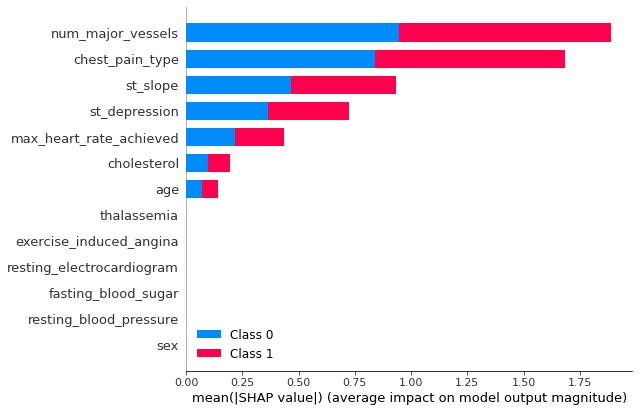

In [ ]:
import shap
shap.initjs()
explainer = shap.TreeExplainer(lgbm)
shap_values = explainer.shap_values(X_val)
shap.summary_plot(shap_values, X_val,
                  feature_names=features,
                  plot_type="bar",
                 )

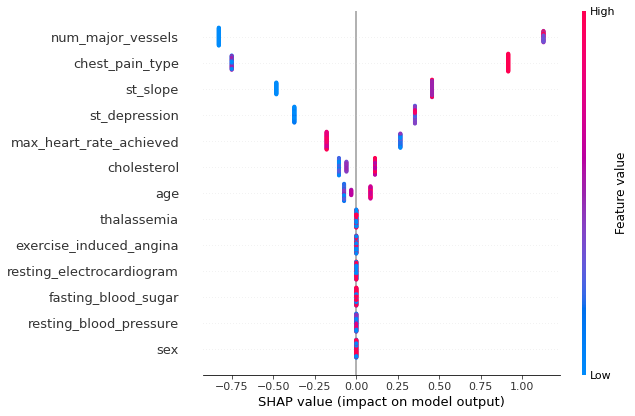

In [ ]:
shap.summary_plot(shap_values[0], X_val)

---
# 3. **Concluding Remark** <a class="anchor" id="3"></a>
---
At the start of this notebook, we laid out what we wanted to do with this project; to explore the heart disease dataset (EDA) and practice binary classification (modeling). In part one (EDA) we did explore the dataset, did a sanity check and removed some 'faulty' data and other pre-processing. We also tried to identify correlation between features and also with the target variable. In part two we practiced how to set-up binary classifiers; first starting with base models and finally arriving at our best model via hyper-parameter tuning. Some of the highlights are summarized below.

- Our best model happens to be LGBM classifier (tuned with randomizedSearch)
- According to both `eli5` permutation importance and `SHAP` the three most important features of the model are `num_major_vessels`, `chest_pain_type`, and `st_slope`. These features are also among better correlated features from our EDA.




# 4. **Reference** <a class="anchor" id="4"></a>

1. https://www.kaggle.com/tentotheminus9/what-causes-heart-disease-explaining-the-model
2. https://towardsdatascience.com/the-search-for-categorical-correlation-a1cf7f1888c9
3. https://scikit-learn.org/stable/auto_examples/classification/plot_classifier_comparison.html
4. https://www.kaggle.com/learn/machine-learning-explainability
5. https://shap.readthedocs.io/en/latest/index.html
6. https://www.healthline.com/health/serum-cholesterol#treatment
7. https://www.who.int/news-room/fact-sheets/detail/cardiovascular-diseases-(cvds)
8. https://www.indushealthplus.com/heart-diseases.html)

## **End of Notebook!**

<blockquote style="margin-right:auto; margin-left:auto; color:white; background-color: #4e4e4e; padding: 1em; margin:24px;">

<font color="white" size=+1.0><b>Thank you for reading!</b></font>
    
<font color="white" size=+1.0><b>If you have any feedback or comments please let me know.</b></font>
    
</blockquote>

<a href="#top">☝️ Back to top</a>